# Homework 2

Daniel Ott (33551440), Samuel Šmíd (73123255), Anna Turnerová (70701808)

For the econometric analysis, we use the datasets from the folder 70701808

## Packages

In [1]:
required_packages <- c("rugarch", "forecast", "FinTS", "ggplot2", "patchwork", "tseries")
  new_packages <- required_packages[!(required_packages %in% installed.packages()[, "Package"])]                                                    
  if (length(new_packages) > 0) install.packages(new_packages)                                                                                      
                                                                                                                                                    
  library(rugarch)   
  library(forecast)                                                                                 
  library(FinTS)                                                                                                           
  library(ggplot2)                                                                                                                      
  library(patchwork) 
  library(tseries)

Installing packages into 'C:/Users/smuld/AppData/Local/R/win-library/4.5'
(as 'lib' is unspecified)

also installing the dependencies 'FNN', 'kernlab', 'mclust', 'multicool', 'pracma', 'DistributionUtils', 'GeneralizedHyperbolic', 'Rsolnp', 'ks', 'spd', 'chron', 'SkewHyperbolic', 'fracdiff', 'urca', 'quadprog'




package 'FNN' successfully unpacked and MD5 sums checked
package 'kernlab' successfully unpacked and MD5 sums checked
package 'mclust' successfully unpacked and MD5 sums checked
package 'multicool' successfully unpacked and MD5 sums checked
package 'pracma' successfully unpacked and MD5 sums checked
package 'DistributionUtils' successfully unpacked and MD5 sums checked
package 'GeneralizedHyperbolic' successfully unpacked and MD5 sums checked
package 'Rsolnp' successfully unpacked and MD5 sums checked
package 'ks' successfully unpacked and MD5 sums checked
package 'spd' successfully unpacked and MD5 sums checked
package 'chron' successfully unpacked and MD5 sums checked
package 'SkewHyperbolic' successfully unpacked and MD5 sums checked
package 'fracdiff' successfully unpacked and MD5 sums checked
package 'urca' successfully unpacked and MD5 sums checked
package 'quadprog' successfully unpacked and MD5 sums checked
package 'rugarch' successfully unpacked and MD5 sums checked
package 'f

Warning message:
"package 'rugarch' was built under R version 4.5.3"
Loading required package: parallel

Warning message:
"package 'forecast' was built under R version 4.5.3"
Warning message:
"package 'FinTS' was built under R version 4.5.3"
Loading required package: zoo


Attaching package: 'zoo'


The following objects are masked from 'package:base':

    as.Date, as.Date.numeric



Attaching package: 'FinTS'


The following object is masked from 'package:forecast':

    Acf


Warning message:
"package 'tseries' was built under R version 4.5.3"
Registered S3 method overwritten by 'quantmod':
  method            from
  as.zoo.data.frame zoo 



#### Problem 0: Loading the data

The folder 70701808 should be placed next to this ipynb file for the data loading to work properly

In [2]:
data_dir <- file.path(getwd(), "70701808")                                                                                                        
  if (!dir.exists(data_dir)) {                                                                                                                      
    stop("Data folder '70701808' not found. Place it in the same directory as this notebook.")                                                      
  }                                                                                                                                                                                                                                           

In [3]:
  # We load the three csv files as data frames
  series_A <- read.csv(file.path(data_dir, "series_A.csv"))                                                                                         
  series_B <- read.csv(file.path(data_dir, "series_B.csv"))                                                                                         
  series_C <- read.csv(file.path(data_dir, "series_C.csv"))                                                                                         
                                                                                                                                                    
  # We extract return series as ts objects (we use it later for the ACF, PACF, ARMA, GARCH)
  ret_A <- ts(series_A$ret)                                                                                                                         
  ret_B <- ts(series_B$ret)
  ret_C <- ts(series_C$ret)

We check if there are any inconsistencies in the data

In [4]:
head(series_A)
head(series_B)
head(series_C)

,t,ret,sigma2_true
,<int>,<dbl>,<dbl>
1,1,0.003333625,1e-04
2,2,-0.014436324,1e-04
3,3,-0.014714092,1e-04
4,4,-0.002892057,1e-04
5,5,-0.001163418,1e-04
6,6,-0.017577014,1e-04


,t,ret,sigma2_true
,<int>,<dbl>,<dbl>
1,1,0.001565492,0.0004319325
2,2,-0.013465665,0.0003565024
3,3,0.002000053,0.0003315146
4,4,-0.019286075,0.0002785568
5,5,-0.013757246,0.0003160698
6,6,0.007472438,0.0003432863


,t,ret,sigma2_true
,<int>,<dbl>,<dbl>
1,1,0.0060400710,8.515252e-05
2,2,-0.0097483423,8.130506e-05
3,3,-0.0004913637,8.327098e-05
4,4,-0.0138233888,7.540007e-05
5,5,0.0132157861,1.042986e-04
6,6,0.0017989999,1.008171e-04


In [5]:
head(series_A$sigma2_true)

[1] 1e-04 1e-04 1e-04 1e-04 1e-04 1e-04

Upon initial inspection, it seems that series A has a constant variance of 0,0001. We verify if there is any variation in the variance

In [6]:
all(series_A$sigma2_true == series_A$sigma2_true[1])                                                                                              
  unique(series_A$sigma2_true) 

[1] TRUE

[1] 1e-04

This verifies that the variance of series_A is constant in all rows. We keep this information in mind for later analysis. Meanwhile we check if there are any missing values (gaps in the series)

In [7]:
for (name in c("series_A", "series_B", "series_C")) {
    df <- get(name)                                                                                                                                 
    cat("---", name, "---\n")                                                                                                                       
    cat("Rows:", nrow(df), "\n")                                                                                                                    
    cat("NAs per column:\n")                                                                                                                        
    print(colSums(is.na(df)))                                                                                                                       
    cat("Expected t sequence (1 to", nrow(df), "):", all(df$t == seq_len(nrow(df))), "\n\n")                                                        
  } 

--- series_A ---
Rows: 4000 
NAs per column:
          t         ret sigma2_true 
          0           0           0 
Expected t sequence (1 to 4000 ): TRUE 

--- series_B ---
Rows: 4000 
NAs per column:
          t         ret sigma2_true 
          0           0           0 
Expected t sequence (1 to 4000 ): TRUE 

--- series_C ---
Rows: 4000 
NAs per column:
          t         ret sigma2_true 
          0           0           0 
Expected t sequence (1 to 4000 ): TRUE 



All three series have the same number of rows and there seem to be no missing values in any column. Lastly, we look for type consistency in the columns.

In [8]:
str(series_A)                                                                                                                                     
str(series_B)
str(series_C) 

'data.frame':	4000 obs. of  3 variables:
 $ t          : int  1 2 3 4 5 6 7 8 9 10 ...
 $ ret        : num  0.00333 -0.01444 -0.01471 -0.00289 -0.00116 ...
 $ sigma2_true: num  1e-04 1e-04 1e-04 1e-04 1e-04 1e-04 1e-04 1e-04 1e-04 1e-04 ...
'data.frame':	4000 obs. of  3 variables:
 $ t          : int  1 2 3 4 5 6 7 8 9 10 ...
 $ ret        : num  0.00157 -0.01347 0.002 -0.01929 -0.01376 ...
 $ sigma2_true: num  0.000432 0.000357 0.000332 0.000279 0.000316 ...
'data.frame':	4000 obs. of  3 variables:
 $ t          : int  1 2 3 4 5 6 7 8 9 10 ...
 $ ret        : num  0.00604 -0.009748 -0.000491 -0.013823 0.013216 ...
 $ sigma2_true: num  8.52e-05 8.13e-05 8.33e-05 7.54e-05 1.04e-04 ...


Seems fine as well, we proceed to the analytic part of this assignment

### Problem 1: Preliminary analysis

In [9]:
# --- Helper: build a single return plot ---                                                                                                      
  make_ret_plot <- function(ret_vec, label) {                                                                                                       
    df <- data.frame(t = seq_along(ret_vec), ret = as.numeric(ret_vec))                                                                             
    ggplot(df, aes(x = t, y = ret)) +                                                                                                               
      geom_line(color = "steelblue", linewidth = 0.3) +                                                                                             
      labs(title = paste("Returns –", label), x = "t", y = "Return") +                                                                              
      theme_minimal()                                                                                                                               
  }                                                                                                                                                 
                                                                                                                                                    
  # --- Helper: build a single squared-return plot ---                                                                                              
  make_sq_plot <- function(ret_vec, label) {
    df <- data.frame(t = seq_along(ret_vec), sq = as.numeric(ret_vec)^2)                                                                            
    ggplot(df, aes(x = t, y = sq)) +                                                                                                                
      geom_line(color = "firebrick", linewidth = 0.3) +                                                                                             
      labs(title = paste("Squared Returns –", label), x = "t", y = expression(Return^2)) +                                                          
      theme_minimal()                                                                                                                               
  }                                                                                                                                                 
                                                                                                                                                    
  # --- Build all 6 panels ---                                                                                                                      
  p_retA <- make_ret_plot(ret_A, "Series A")
  p_retB <- make_ret_plot(ret_B, "Series B")                                                                                                        
  p_retC <- make_ret_plot(ret_C, "Series C")                                                                                                        
                                                                                                                                                    
  p_sqA  <- make_sq_plot(ret_A, "Series A")                                                                                                         
  p_sqB  <- make_sq_plot(ret_B, "Series B")                                                                                                         
  p_sqC  <- make_sq_plot(ret_C, "Series C")      

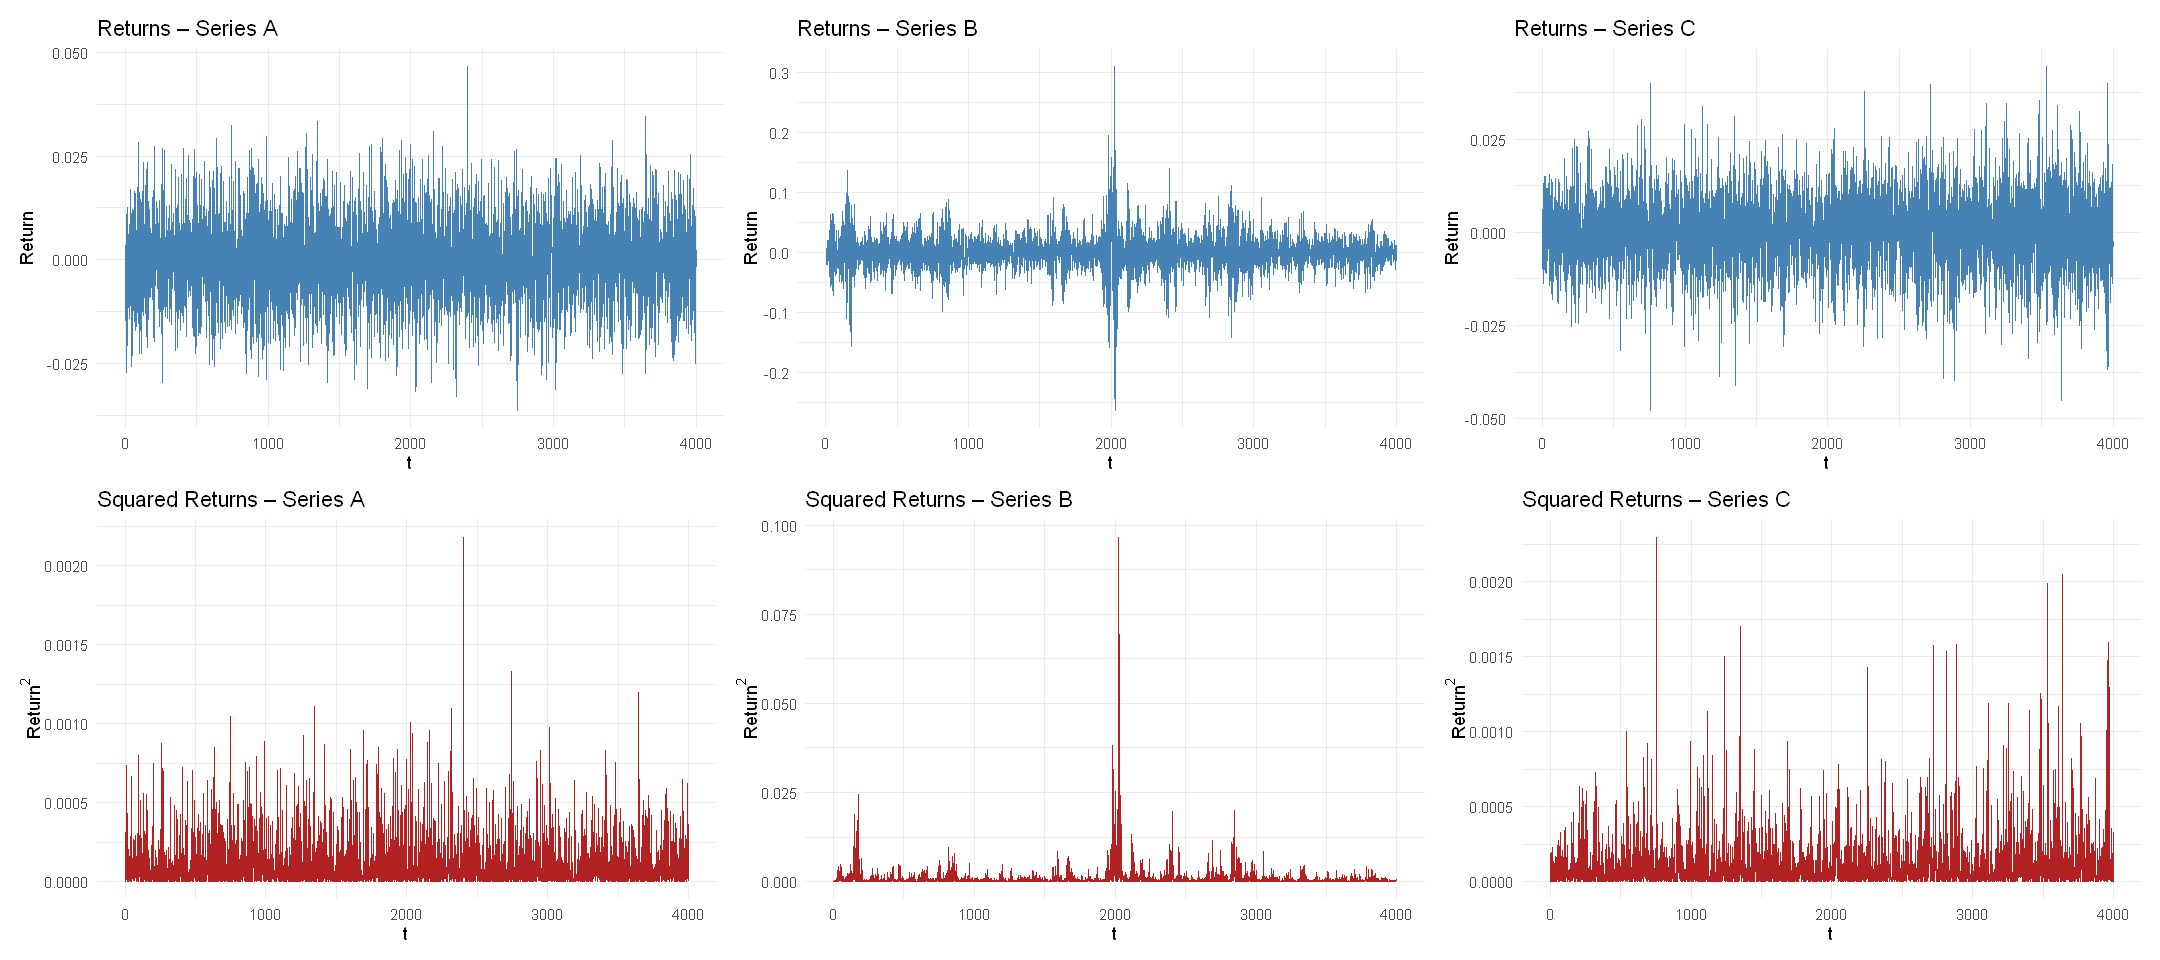

In [10]:
 # --- Combine: returns on top row, squared returns on bottom row ---                                                                              
options(repr.plot.width = 18, repr.plot.height = 8)                                                                                               
  (p_retA | p_retB | p_retC) / (p_sqA | p_sqB | p_sqC)

Based on visual inspection, we form the following hypotheses about volatility clustering of the series:
* **least persistent volatilty clustering**: Series A - The returns seem to fluctuate uniformly throughout the entire sample and the squared returns show no apparent pattern. The spikes seem to be randomly scattered. This is in line with the fact that the variance of Series A is constant across all time periods. 
* **most persistent volatility clustering**: Series B - Around observation 2000, the series enters a period of extreme volatility with returns exceeding 0.2 in magnitude, before slowly calming down. The squared returns make this especially clear. One dominant cluster around t = 2000 that is far larger than anything else in the sample, with higher variance persisting for a long time afterwards.
* **intermediate volatility clustering**: Series C - Rather than one dramatic episode, the series shows multiple periods of higher and lower volatility scattered throughout the sample. The squared returns show recurring clusters of large spikes that appear and fade, suggesting volatility that reacts to shocks but settles down faster than in Series B.

### Problem 2:  Identification of the conditional mean

From previous analysis all time series of returns seem to be stationary, lets compare the visual inspection with formal test.

In [11]:
print(adf.test(series_A$ret, k = 1))
print(adf.test(series_B$ret, k = 1))
print(adf.test(series_C$ret, k = 1))

Warning message in adf.test(series_A$ret, k = 1):
"p-value smaller than printed p-value"



	Augmented Dickey-Fuller Test

data:  series_A$ret
Dickey-Fuller = -55.943, Lag order = 1, p-value = 0.01
alternative hypothesis: stationary



Warning message in adf.test(series_B$ret, k = 1):
"p-value smaller than printed p-value"



	Augmented Dickey-Fuller Test

data:  series_B$ret
Dickey-Fuller = -50.839, Lag order = 1, p-value = 0.01
alternative hypothesis: stationary



Warning message in adf.test(series_C$ret, k = 1):
"p-value smaller than printed p-value"



	Augmented Dickey-Fuller Test

data:  series_C$ret
Dickey-Fuller = -54.29, Lag order = 1, p-value = 0.01
alternative hypothesis: stationary



Our visual inspection of stationarity was confirmed with the formal test, therefore the mean model will be ARMA since the additional parameter in ARIMA is not needed.
Lets continue with plotting ACF and PACF to inspect the data further

#### Series A Box-Jenkins

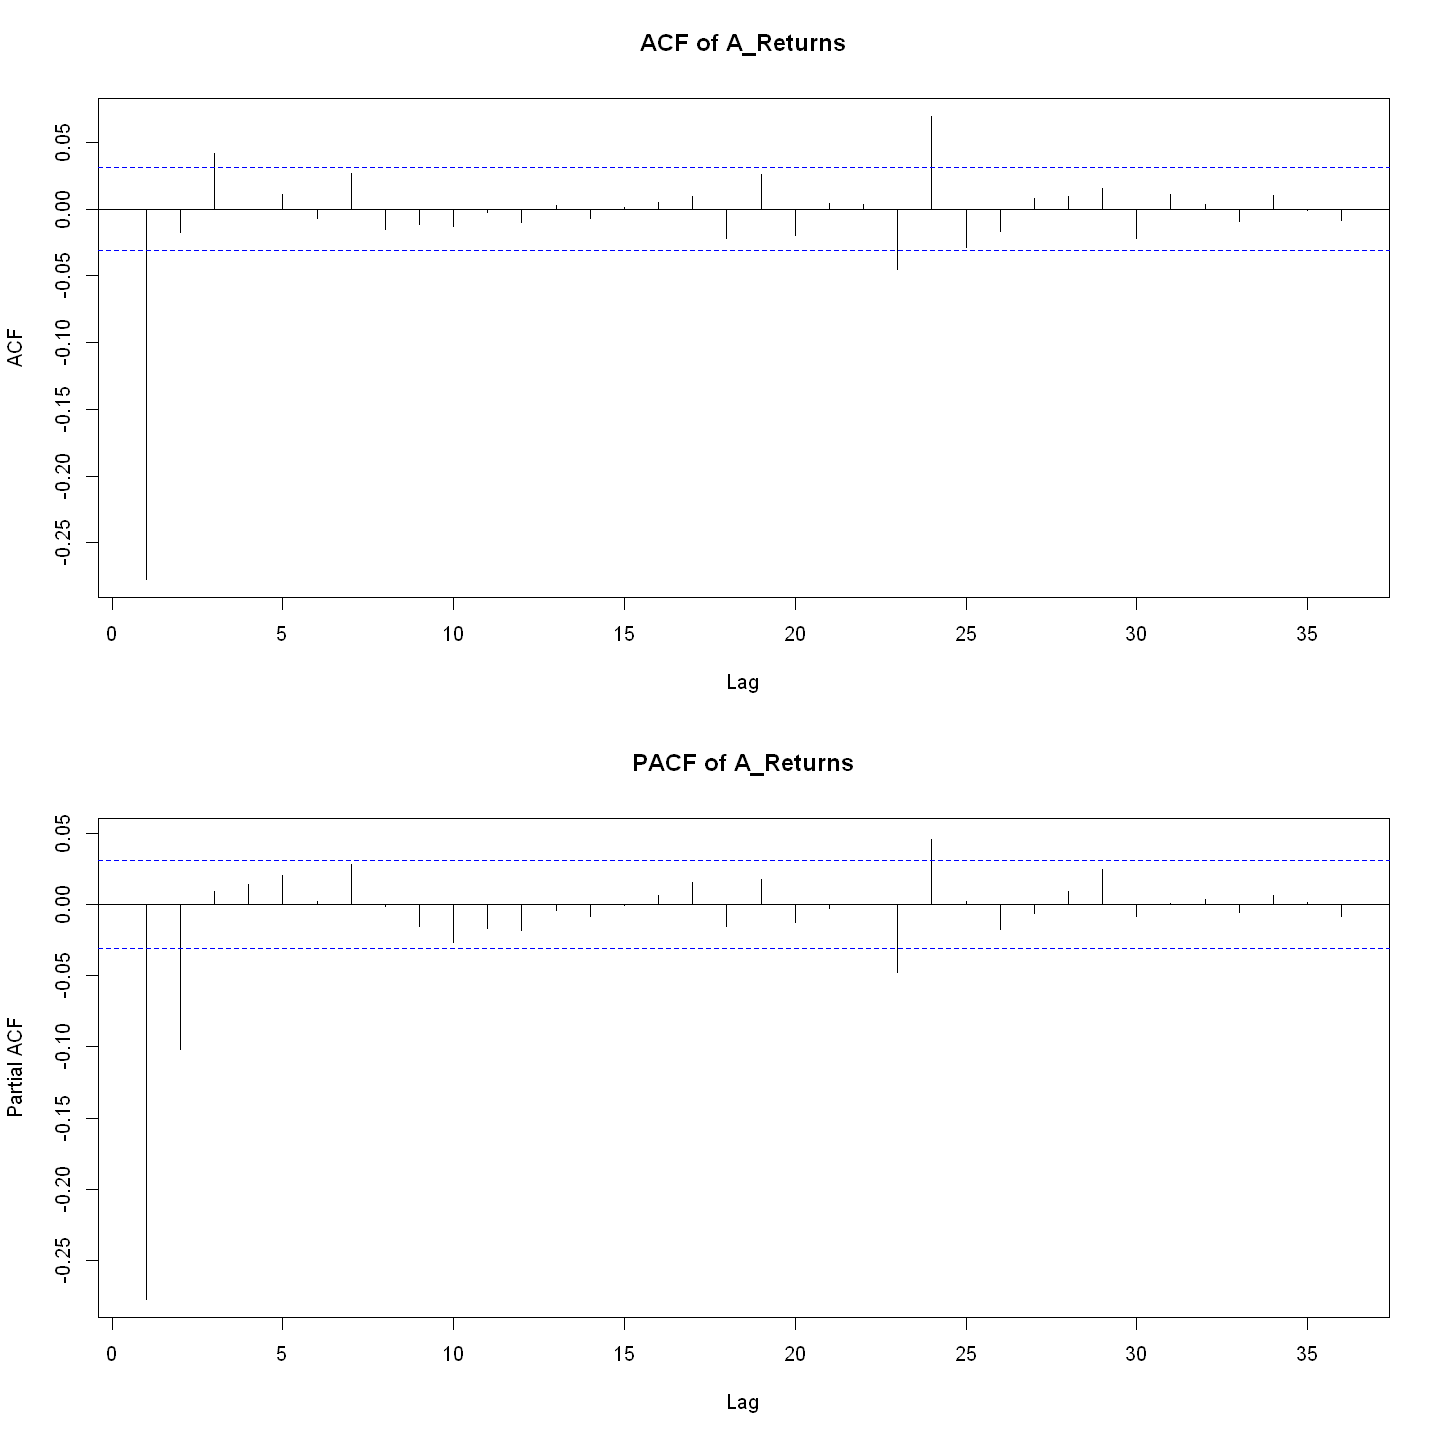

In [12]:
options(repr.plot.width = 12, repr.plot.height = 12)
par(mfrow = c(2, 1))
Acf(series_A$ret, main="ACF of A_Returns")
Pacf(series_A$ret, main="PACF of A_Returns")

**ACF** cuts off after first lag, with barely significant lag 3 and **PACF**  cuts off after significant 1st and 2nd lags. Since both ACF and PACF drop imidiately after the respective lags, we suspect either AR or MA process. We would expect MA(1), AR(2), to be most likely and further we estimate ARMA(1,1) for comparison. We do not include further lags to prevent overfitting, as in seminar the key takeaway was to keep these types of models simple. We expect the MA(1) to be most suitable since the PACF does not drop as rapidly and the ACF does so.

In [13]:
A_ma1 <- Arima(series_A$ret, order = c(0, 0, 1))
summary(A_ma1)
A_ar2 <- Arima(series_A$ret, order = c(2, 0, 0))
summary(A_ar2)
A_arma11 <- Arima(series_A$ret, order = c(1, 0, 1))
summary(A_arma11)

Series: series_A$ret 
ARIMA(0,0,1) with non-zero mean 

Coefficients:
          ma1   mean
      -0.3012  1e-04
s.e.   0.0147  1e-04

sigma^2 = 0.0001008:  log likelihood = 12729.8
AIC=-25453.59   AICc=-25453.59   BIC=-25434.71

Training set error measures:
                        ME       RMSE        MAE      MPE     MAPE      MASE
Training set -4.622998e-08 0.01003778 0.00798011 106.2978 207.3473 0.5986774
                    ACF1
Training set -0.00296057

Series: series_A$ret 
ARIMA(2,0,0) with non-zero mean 

Coefficients:
          ar1      ar2   mean
      -0.3052  -0.1019  1e-04
s.e.   0.0157   0.0157  1e-04

sigma^2 = 0.0001006:  log likelihood = 12733.43
AIC=-25458.86   AICc=-25458.85   BIC=-25433.68

Training set error measures:
                        ME       RMSE         MAE      MPE     MAPE      MASE
Training set -4.791682e-07 0.01002866 0.007974574 103.2031 208.6005 0.5982621
                     ACF1
Training set 0.0008316948

Series: series_A$ret 
ARIMA(1,0,1) with non-zero mean 

Coefficients:
          ar1      ma1   mean
      -0.0262  -0.2781  1e-04
s.e.   0.0459   0.0434  1e-04

sigma^2 = 0.0001008:  log likelihood = 12729.94
AIC=-25451.88   AICc=-25451.87   BIC=-25426.7

Training set error measures:
                       ME       RMSE         MAE      MPE     MAPE      MASE
Training set 4.848184e-08 0.01003742 0.007981725 105.7151 208.6477 0.5987986
                      ACF1
Training set -0.0002441463

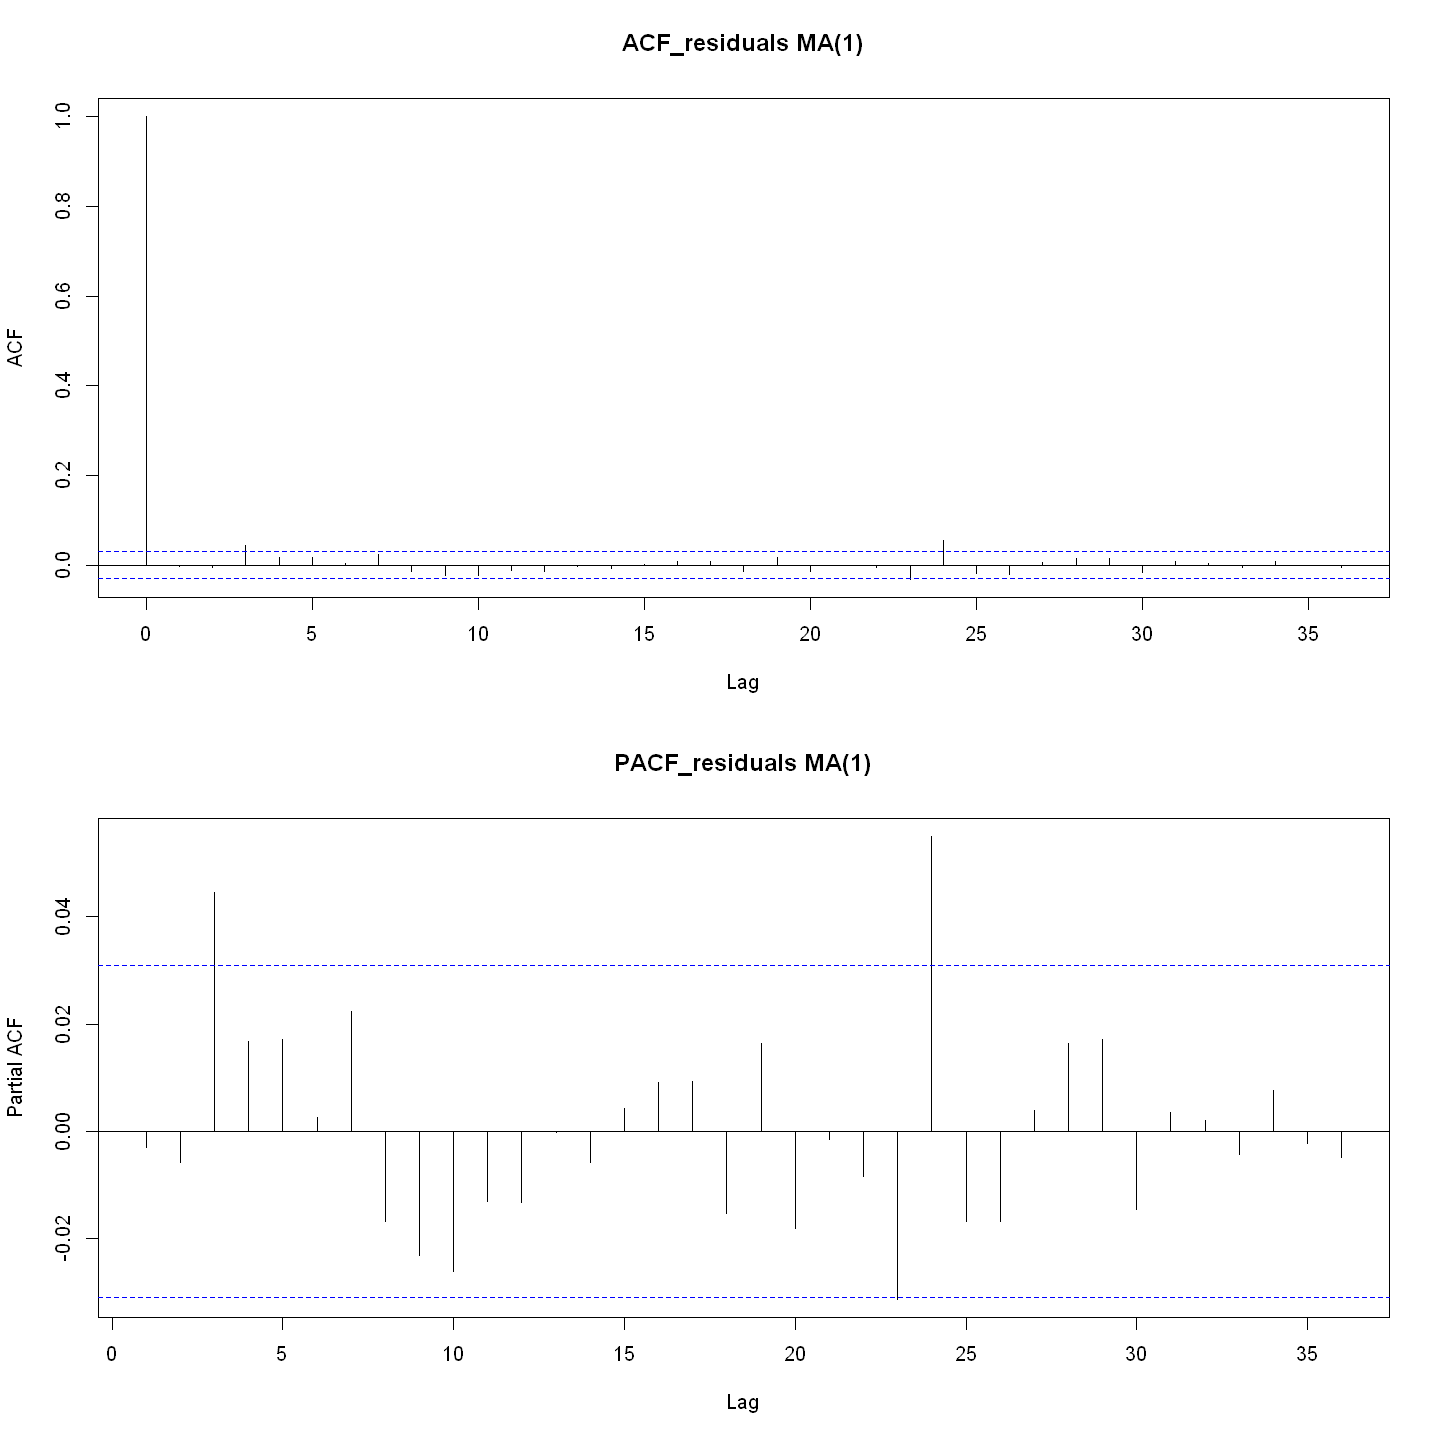

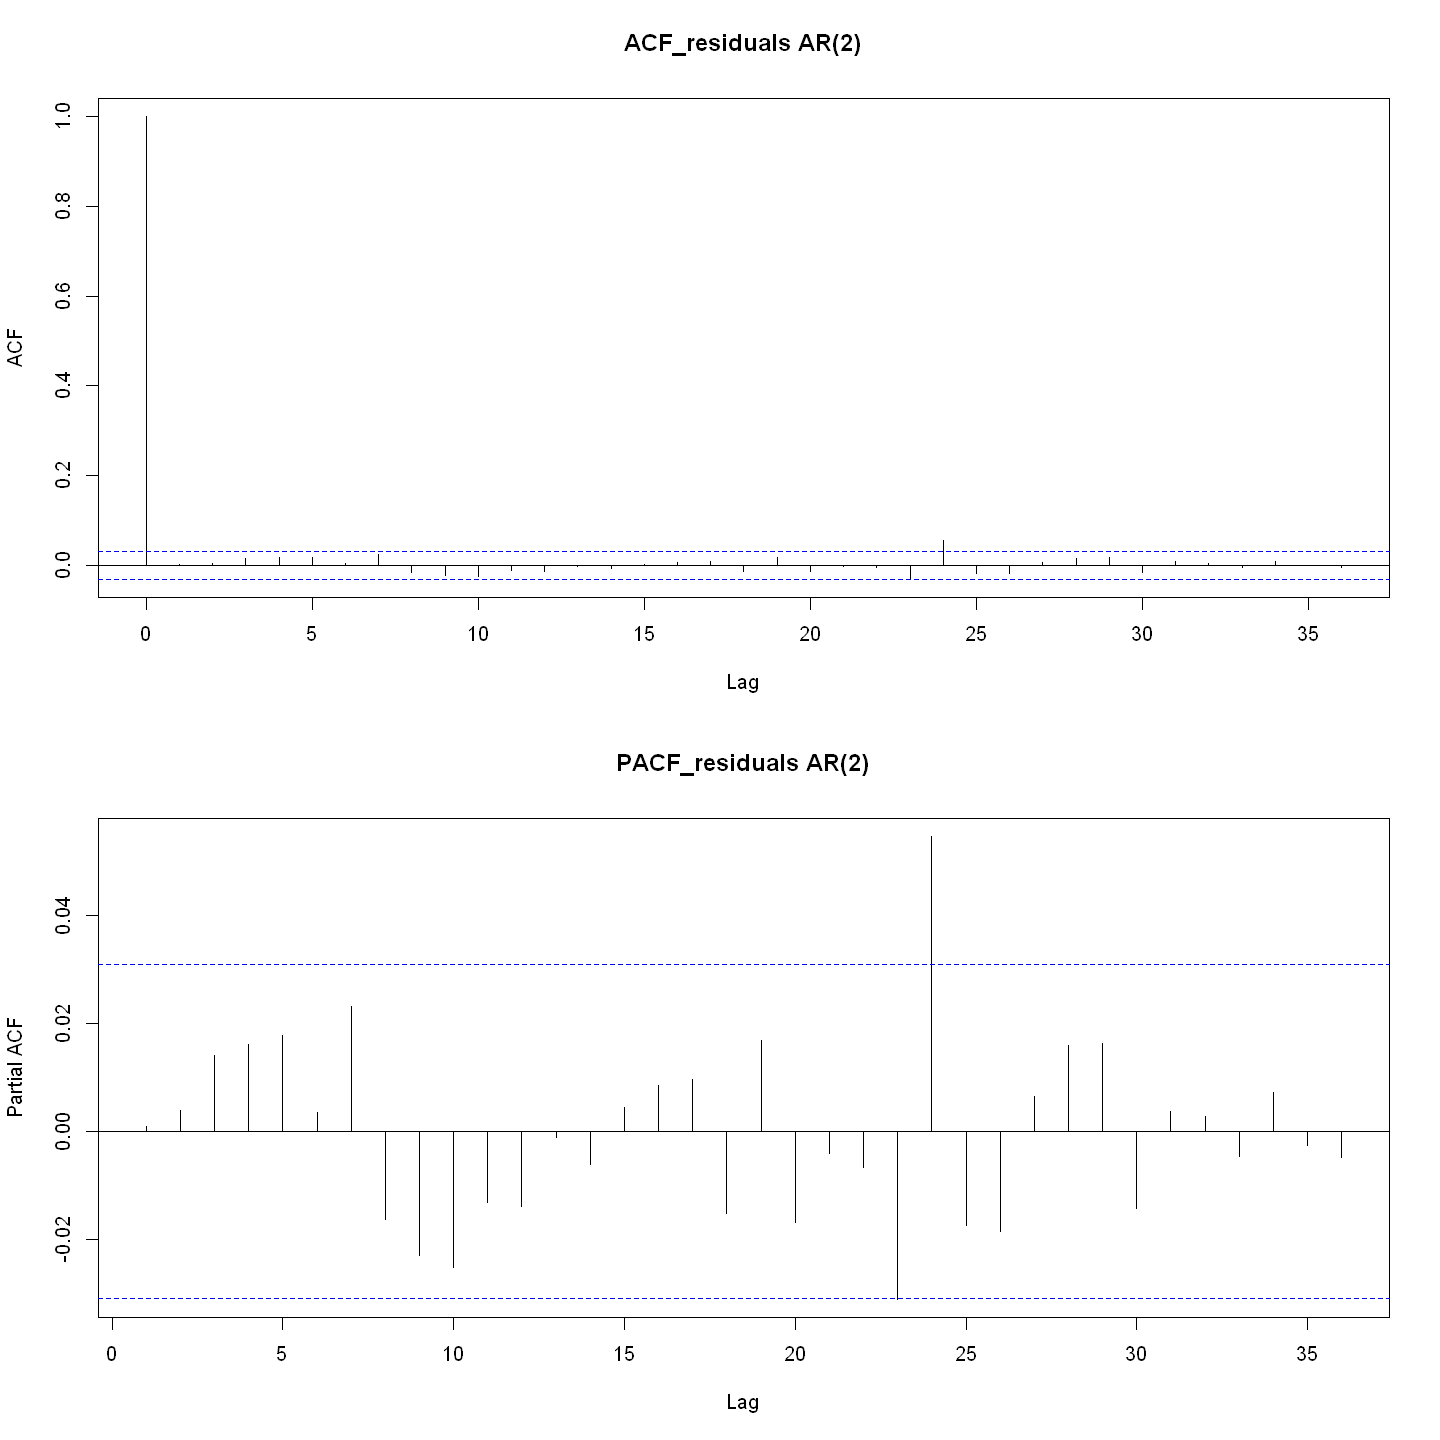

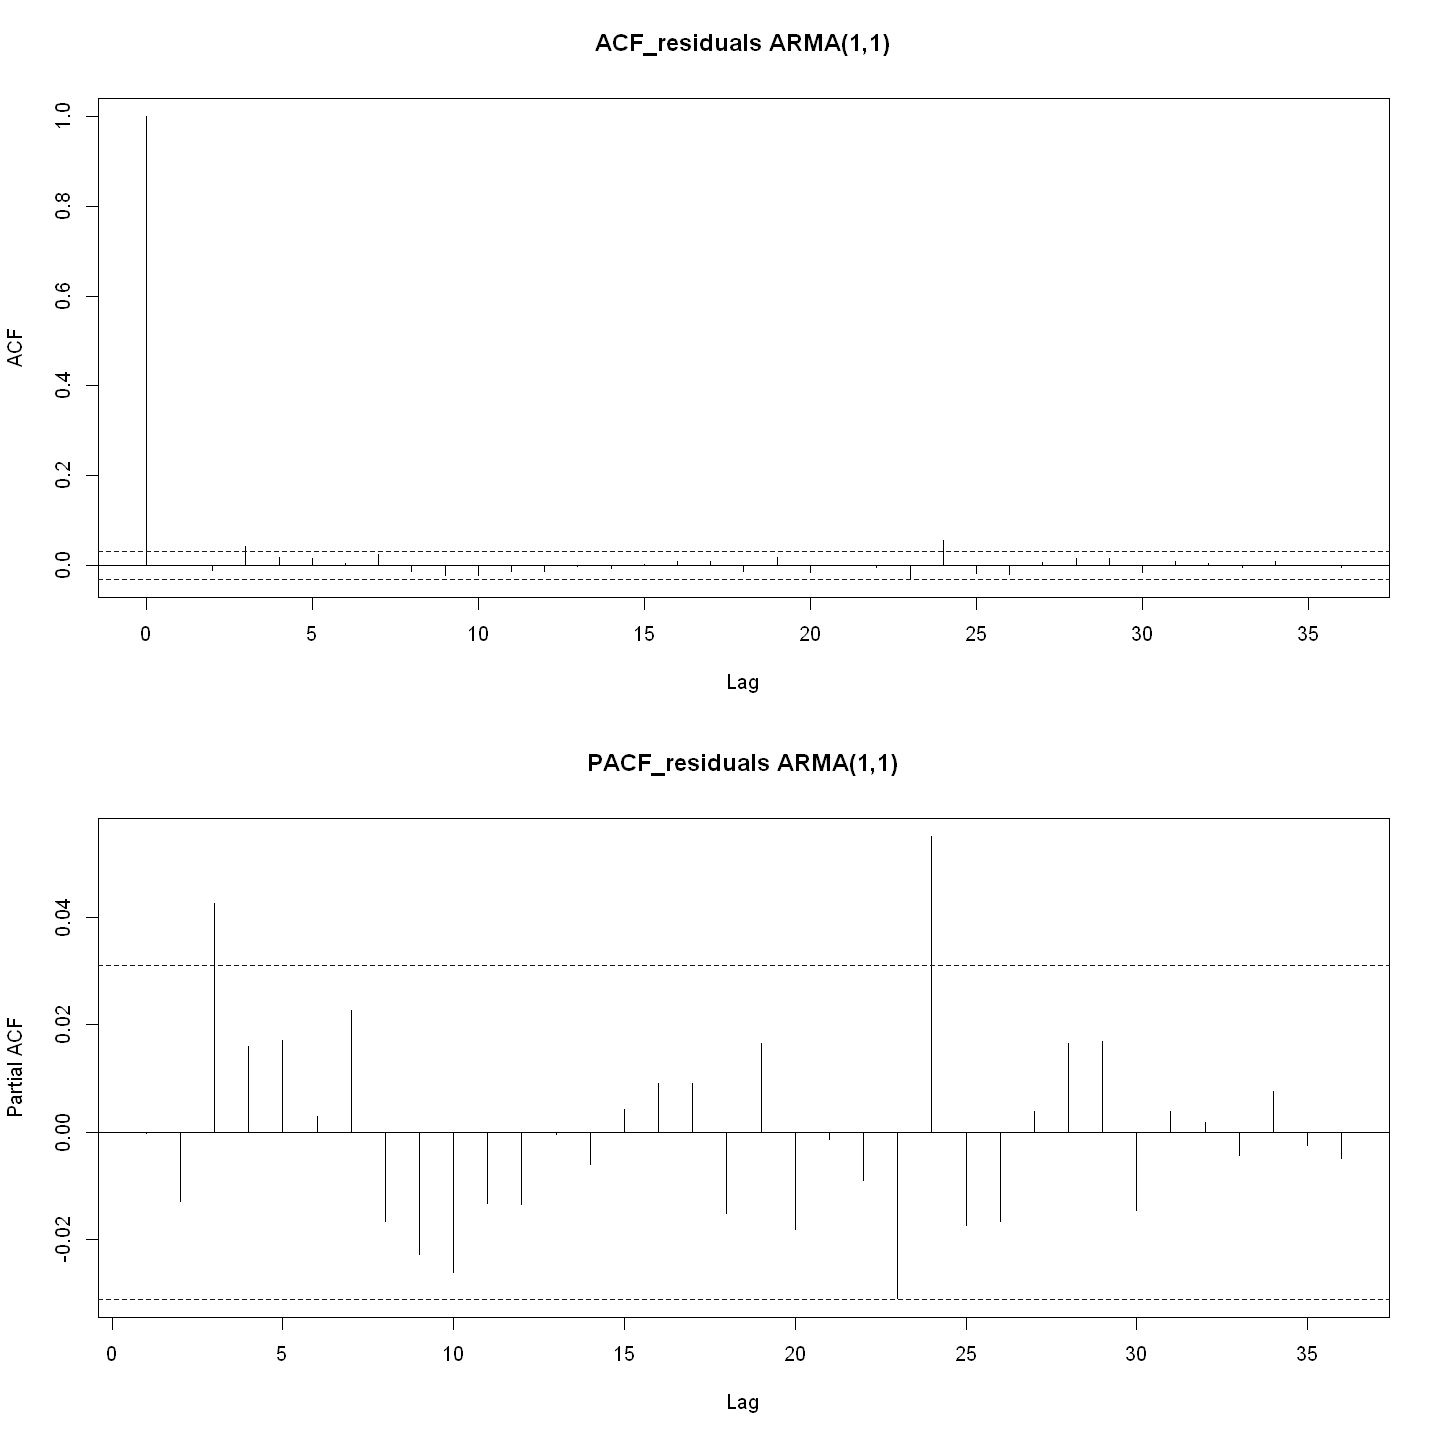

In [14]:
par(mfrow = c(2,1 ))
acf(A_ma1$residuals, main = "ACF_residuals MA(1)")
pacf(A_ma1$residuals, main = "PACF_residuals MA(1)")
acf(A_ar2$residuals, main = "ACF_residuals AR(2)")
pacf(A_ar2$residuals, main = "PACF_residuals AR(2)")
acf(A_arma11$residuals, main = "ACF_residuals ARMA(1,1)")
pacf(A_arma11$residuals, main = "PACF_residuals ARMA(1,1)")

In [15]:
Box.test(A_ma1$residuals, type = "Ljung-Box", lag = 4)
Box.test(A_ma1$residuals, type = "Ljung-Box", lag = 8)
Box.test(A_ma1$residuals, type = "Ljung-Box", lag = 12)
Box.test(A_ar2$residuals, type = "Ljung-Box", lag = 4)
Box.test(A_ar2$residuals, type = "Ljung-Box", lag = 8)
Box.test(A_ar2$residuals, type = "Ljung-Box", lag = 12)
Box.test(A_arma11$residuals, type = "Ljung-Box", lag = 4)
Box.test(A_arma11$residuals, type = "Ljung-Box", lag = 8)
Box.test(A_arma11$residuals, type = "Ljung-Box", lag = 12)


	Box-Ljung test

data:  A_ma1$residuals
X-squared = 9.2267, df = 4, p-value = 0.05568



	Box-Ljung test

data:  A_ma1$residuals
X-squared = 13.521, df = 8, p-value = 0.09514



	Box-Ljung test

data:  A_ma1$residuals
X-squared = 19.181, df = 12, p-value = 0.08424



	Box-Ljung test

data:  A_ar2$residuals
X-squared = 1.8972, df = 4, p-value = 0.7547



	Box-Ljung test

data:  A_ar2$residuals
X-squared = 6.448, df = 8, p-value = 0.5972



	Box-Ljung test

data:  A_ar2$residuals
X-squared = 12.226, df = 12, p-value = 0.4277



	Box-Ljung test

data:  A_arma11$residuals
X-squared = 8.9645, df = 4, p-value = 0.06199



	Box-Ljung test

data:  A_arma11$residuals
X-squared = 13.18, df = 8, p-value = 0.1058



	Box-Ljung test

data:  A_arma11$residuals
X-squared = 18.831, df = 12, p-value = 0.09269


In [16]:
models <- 3
criteria <- matrix(ncol = 2, nrow = models)
colnames(criteria) <- c('AIC', 'BIC')
rownames(criteria) <- c('MA(1)','AR(2)' ,'ARMA(1,1)')

criteria[1, 1] <- A_ma1$aic
criteria[1, 2] <- A_ma1$bic
criteria[2, 1] <- A_ar2$aic
criteria[2, 2] <- A_ar2$bic
criteria[3, 1] <- A_arma11$aic
criteria[3, 2] <- A_arma11$bic

criteria

,AIC,BIC
MA(1),-25453.59,-25434.71
AR(2),-25458.86,-25433.68
"ARMA(1,1)",-25451.88,-25426.70


BIC is compensating for the amount of parameter estimates, therefore it gets closer to zero in this case for models with more parameters

The structure of the ACF and PACF suggests candidate models MA(1), AR(2) and ARMA (1,1). Interpreting the coefficients of the estimated models, we first eliminate the ARMA(1,1) specification because its AR(1) parameter is statistically insignificant, indicating that the model is overparametrised. Now, we need to choose between the remaining AR(2) and MA(1) models. Information criteria are inconclusive -- while the AIC slightly prefers AR(2), the BIC prefers the MA(1) model. In the end, we prefer **MA(1)** as the mean model for Series A due to the fact that the second lag in the PACF is much smaller in magnitude than the first one (suggesting decay expected from a MA process rather than a true AR effect), and because it is simpler. Furthermore, the AR coefficient on the ARMA(1,1) specification was small and insignificant, suggesting that a MA model better fits the returns structure of Series A.

#### Series B Box-Jenkins

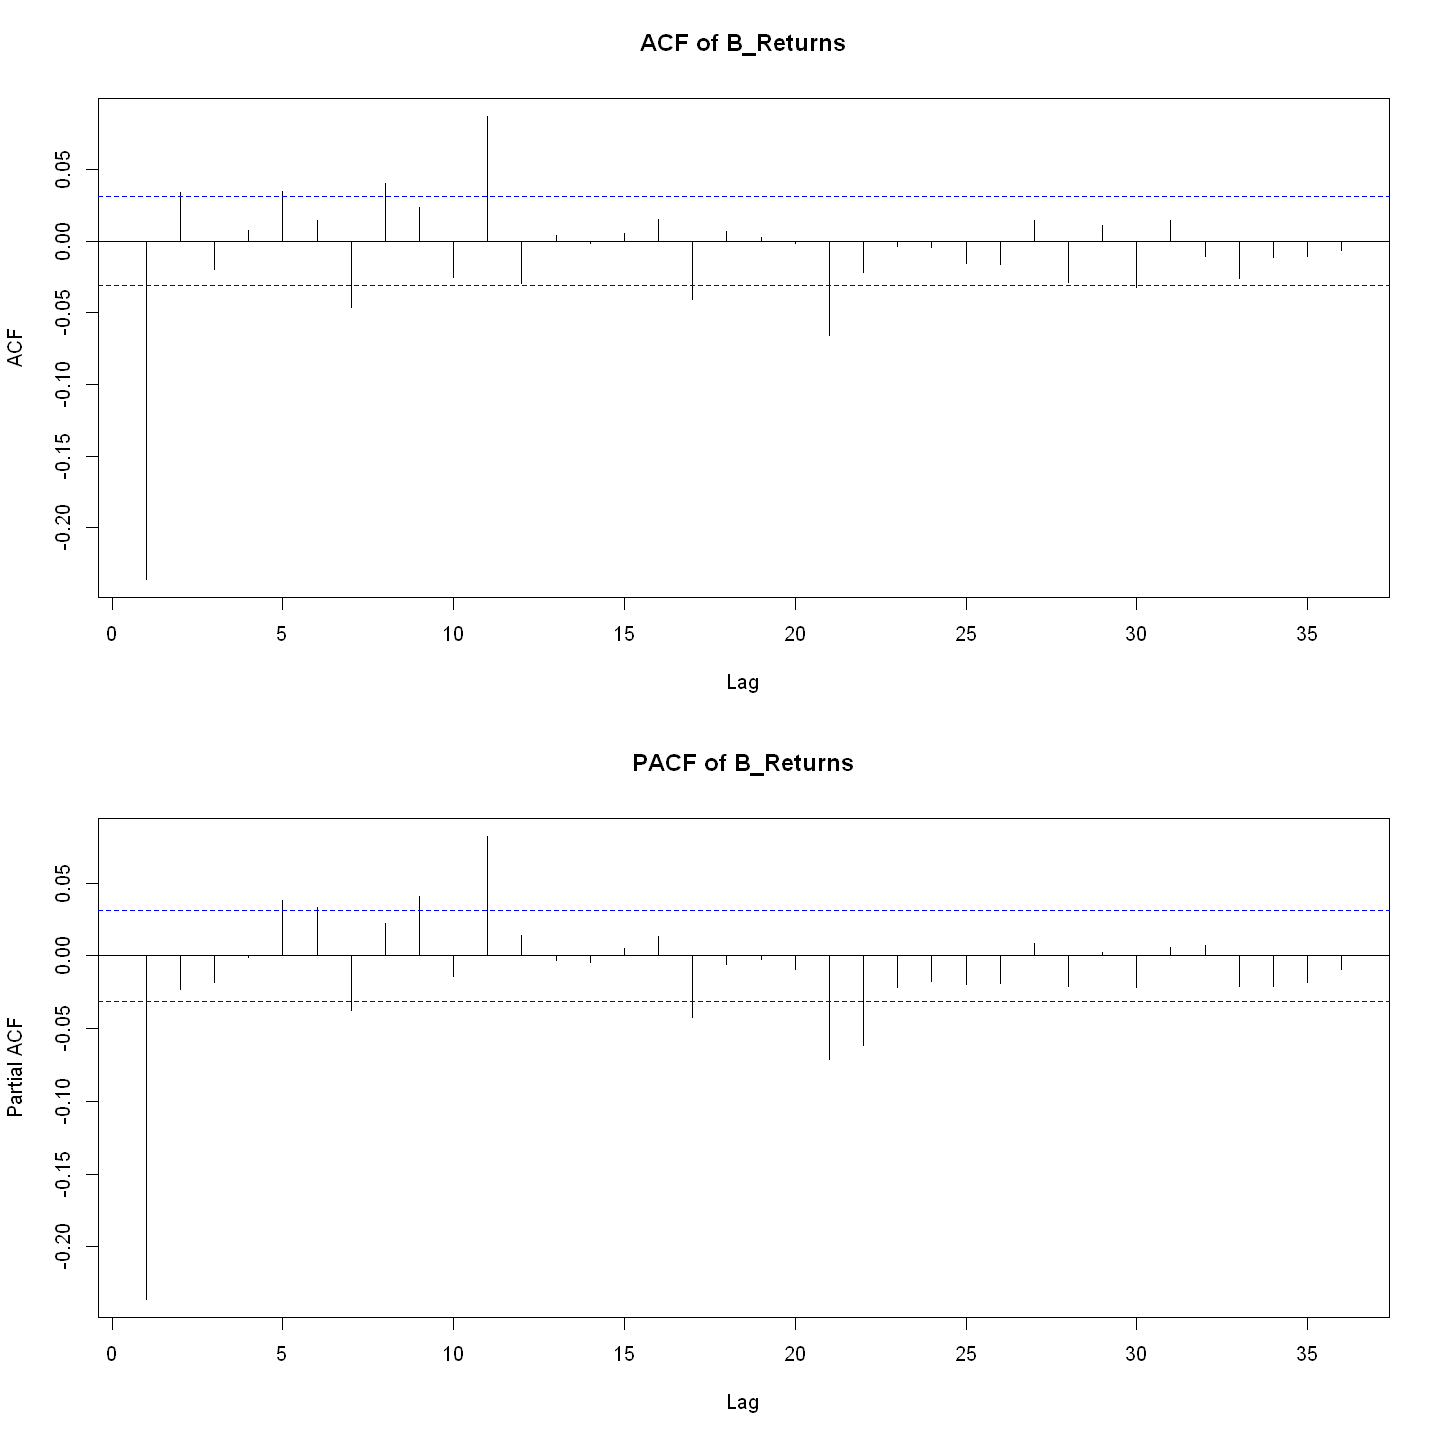

In [17]:
options(repr.plot.width = 12, repr.plot.height = 12)
par(mfrow = c(2, 1))
Acf(series_B$ret, main="ACF of B_Returns")
Pacf(series_B$ret, main="PACF of B_Returns")

The ACF and PACF  have similar pattern as the series A. However here there is no significant further lag than one and the later lags such as the 11th we do not want to estimate to keep the simplicity in the model. In this series we expect the volatility modelling to be the better model as the volatility is clustered as shown in problem 1. Most plausible models to estimate are the MA(1), AR(1) and ARMA(1,1)

In [18]:
B_ma1 <- Arima(series_B$ret, order = c(0, 0, 1))
summary(B_ma1)
B_ar1 <- Arima(series_B$ret, order = c(1, 0, 0))
summary(B_ar1)
B_arma11 <- Arima(series_B$ret, order = c(1, 0, 1))
summary(B_arma11)

Series: series_B$ret 
ARIMA(0,0,1) with non-zero mean 

Coefficients:
          ma1   mean
      -0.2352  0e+00
s.e.   0.0149  4e-04

sigma^2 = 0.0008873:  log likelihood = 8379.91
AIC=-16753.83   AICc=-16753.82   BIC=-16734.94

Training set error measures:
                       ME       RMSE        MAE      MPE     MAPE      MASE
Training set 3.644207e-08 0.02977983 0.02070669 146.0402 256.0495 0.6235934
                     ACF1
Training set -0.006953821

Series: series_B$ret 
ARIMA(1,0,0) with non-zero mean 

Coefficients:
          ar1   mean
      -0.2358  0e+00
s.e.   0.0154  4e-04

sigma^2 = 0.000887:  log likelihood = 8380.48
AIC=-16754.96   AICc=-16754.95   BIC=-16736.08

Training set error measures:
                       ME       RMSE        MAE      MPE     MAPE      MASE
Training set 2.027819e-07 0.02977561 0.02070193 170.3504 275.6803 0.6234501
                     ACF1
Training set -0.005487077

Series: series_B$ret 
ARIMA(1,0,1) with non-zero mean 

Coefficients:
          ar1      ma1   mean
      -0.1308  -0.1113  0e+00
s.e.   0.0690   0.0694  4e-04

sigma^2 = 0.0008867:  log likelihood = 8381.71
AIC=-16755.42   AICc=-16755.41   BIC=-16730.24

Training set error measures:
                        ME       RMSE        MAE      MPE     MAPE      MASE
Training set -1.748854e-09 0.02976646 0.02069379 160.8253 271.8842 0.6232048
                     ACF1
Training set 0.0003941563

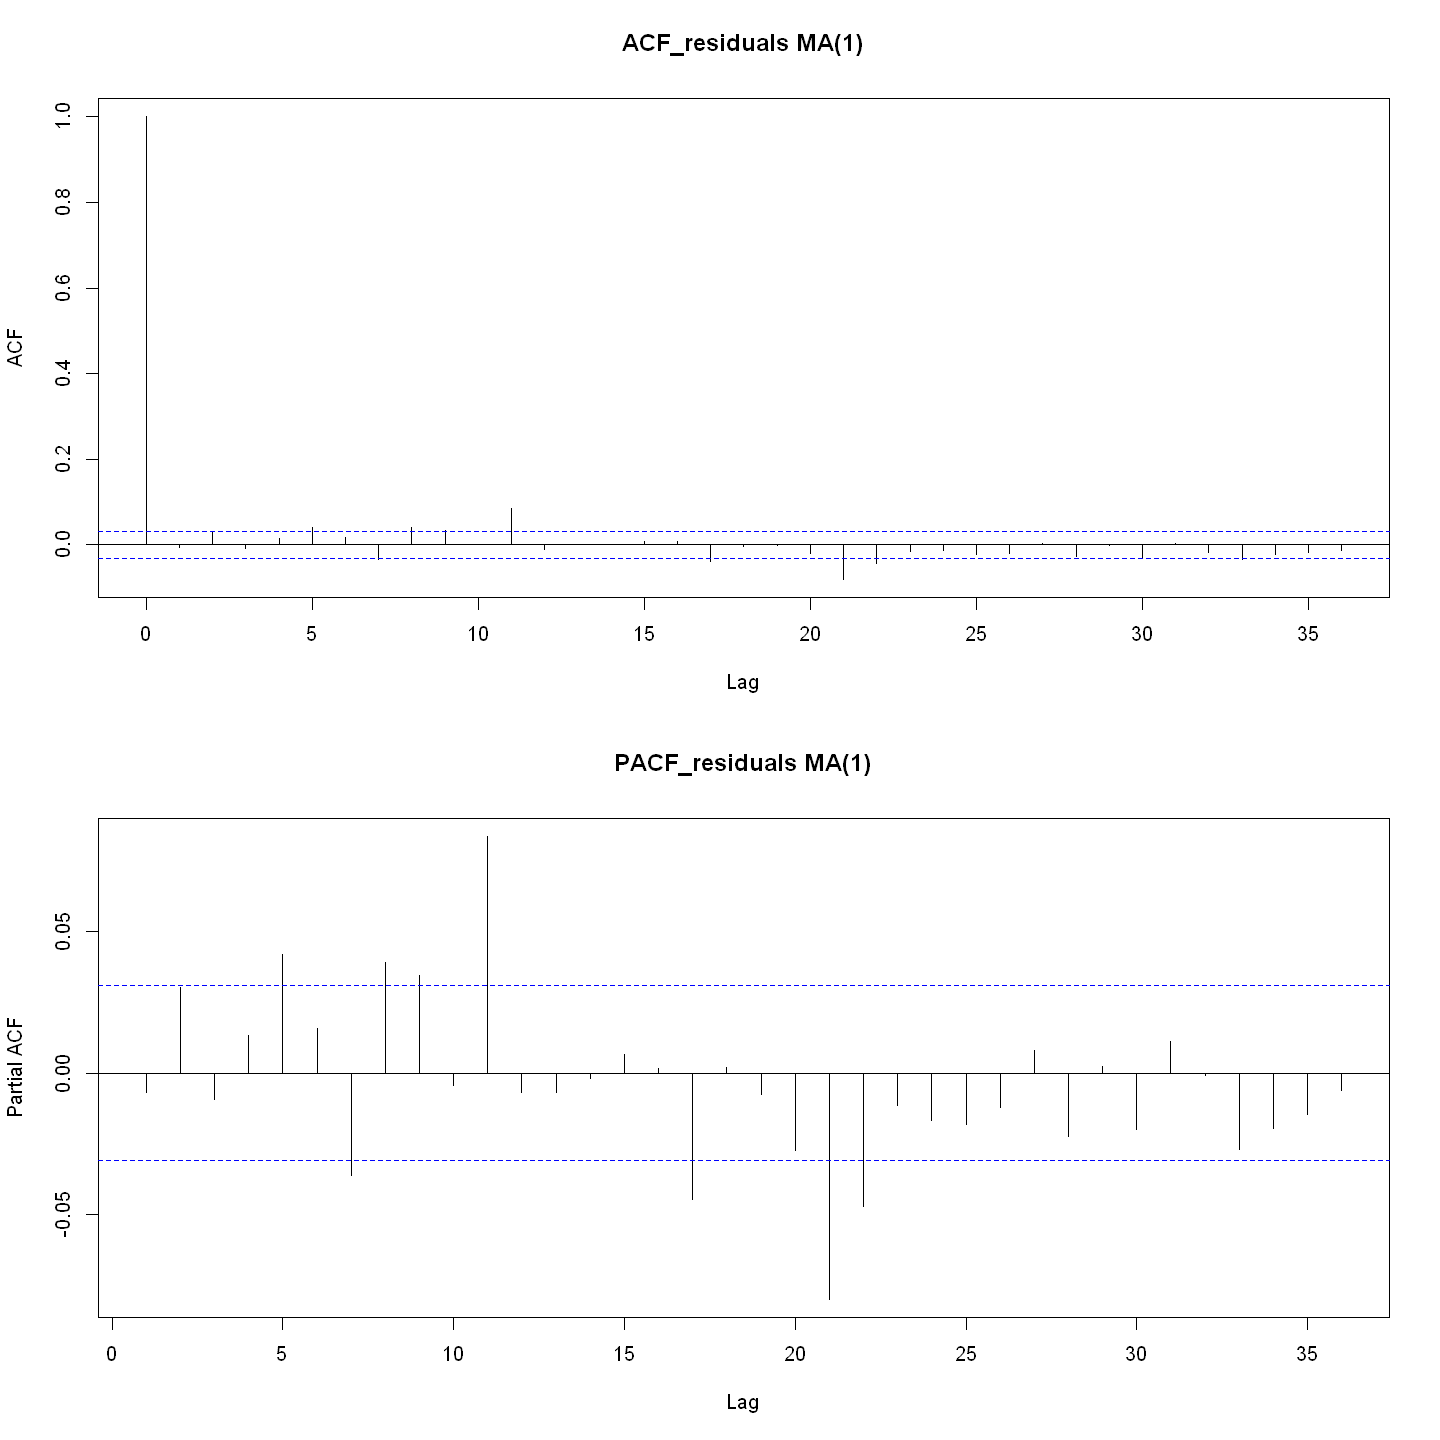

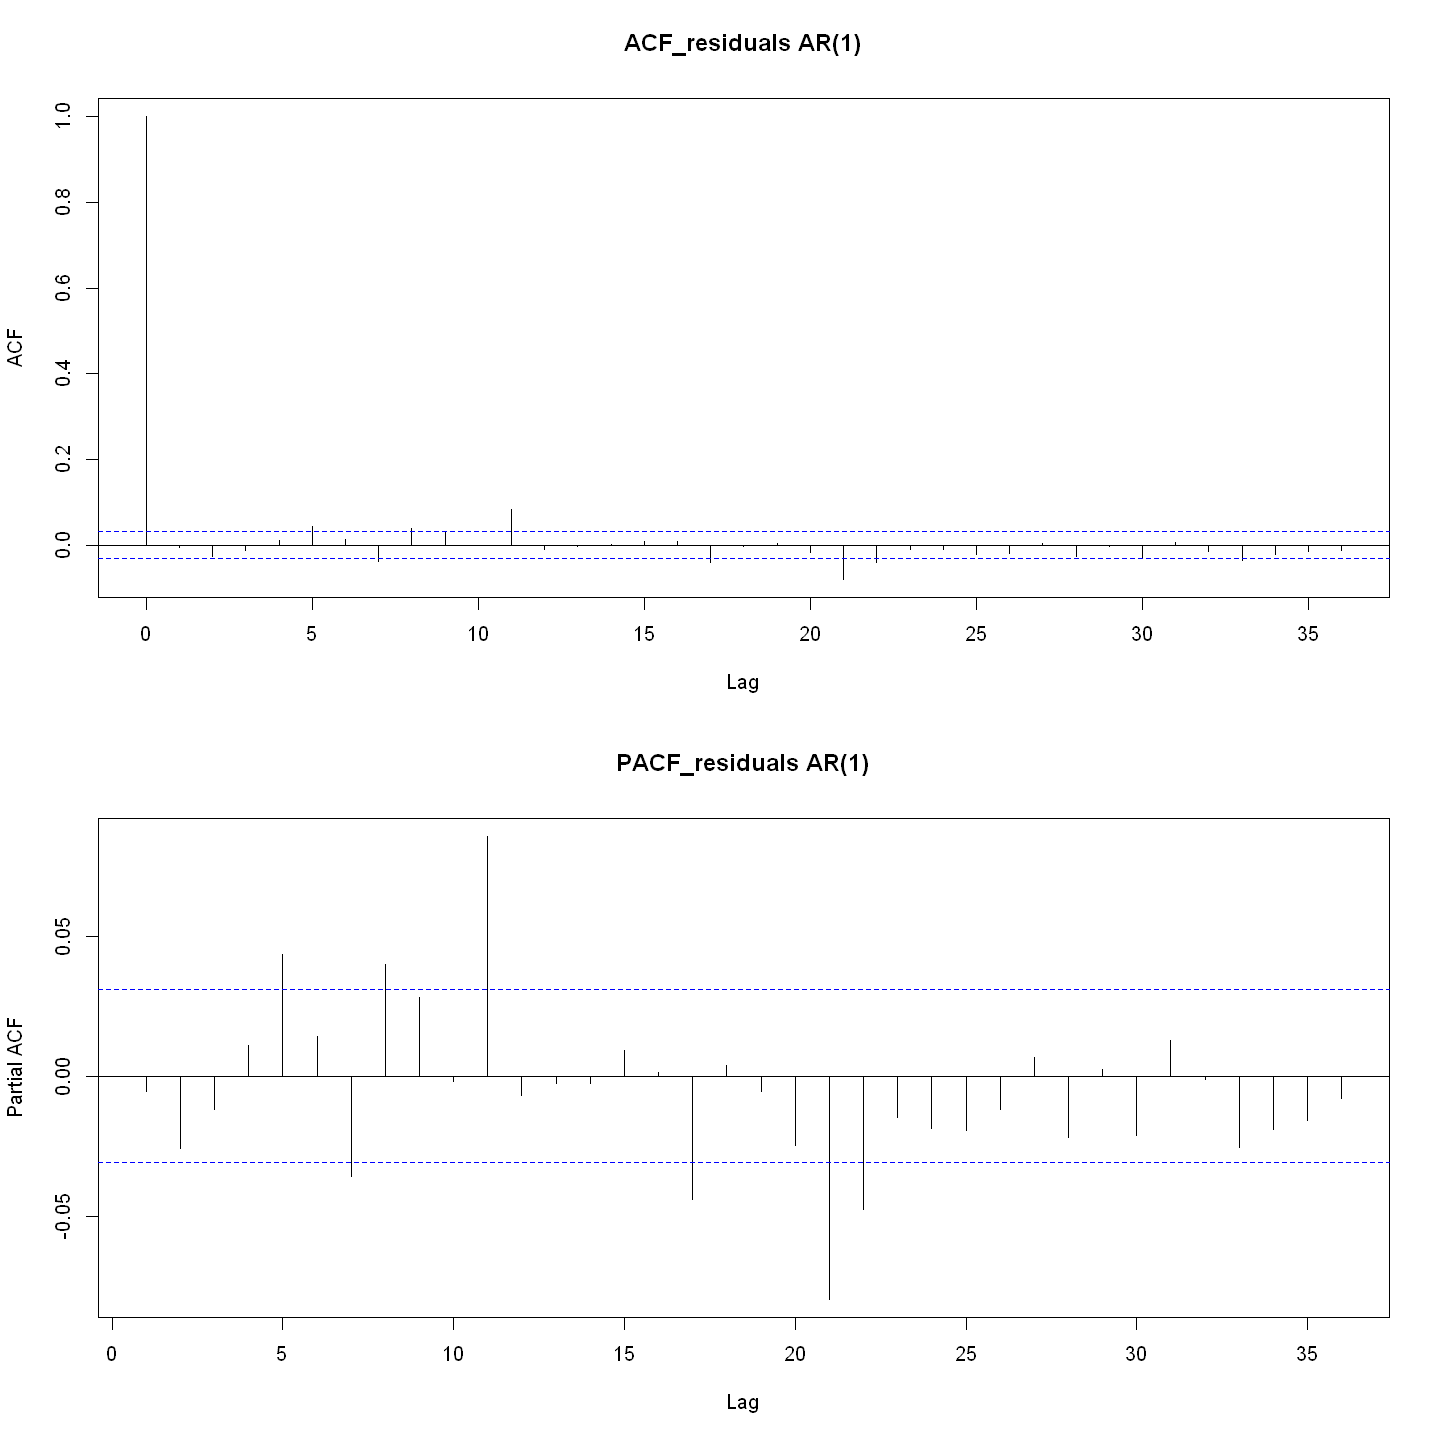

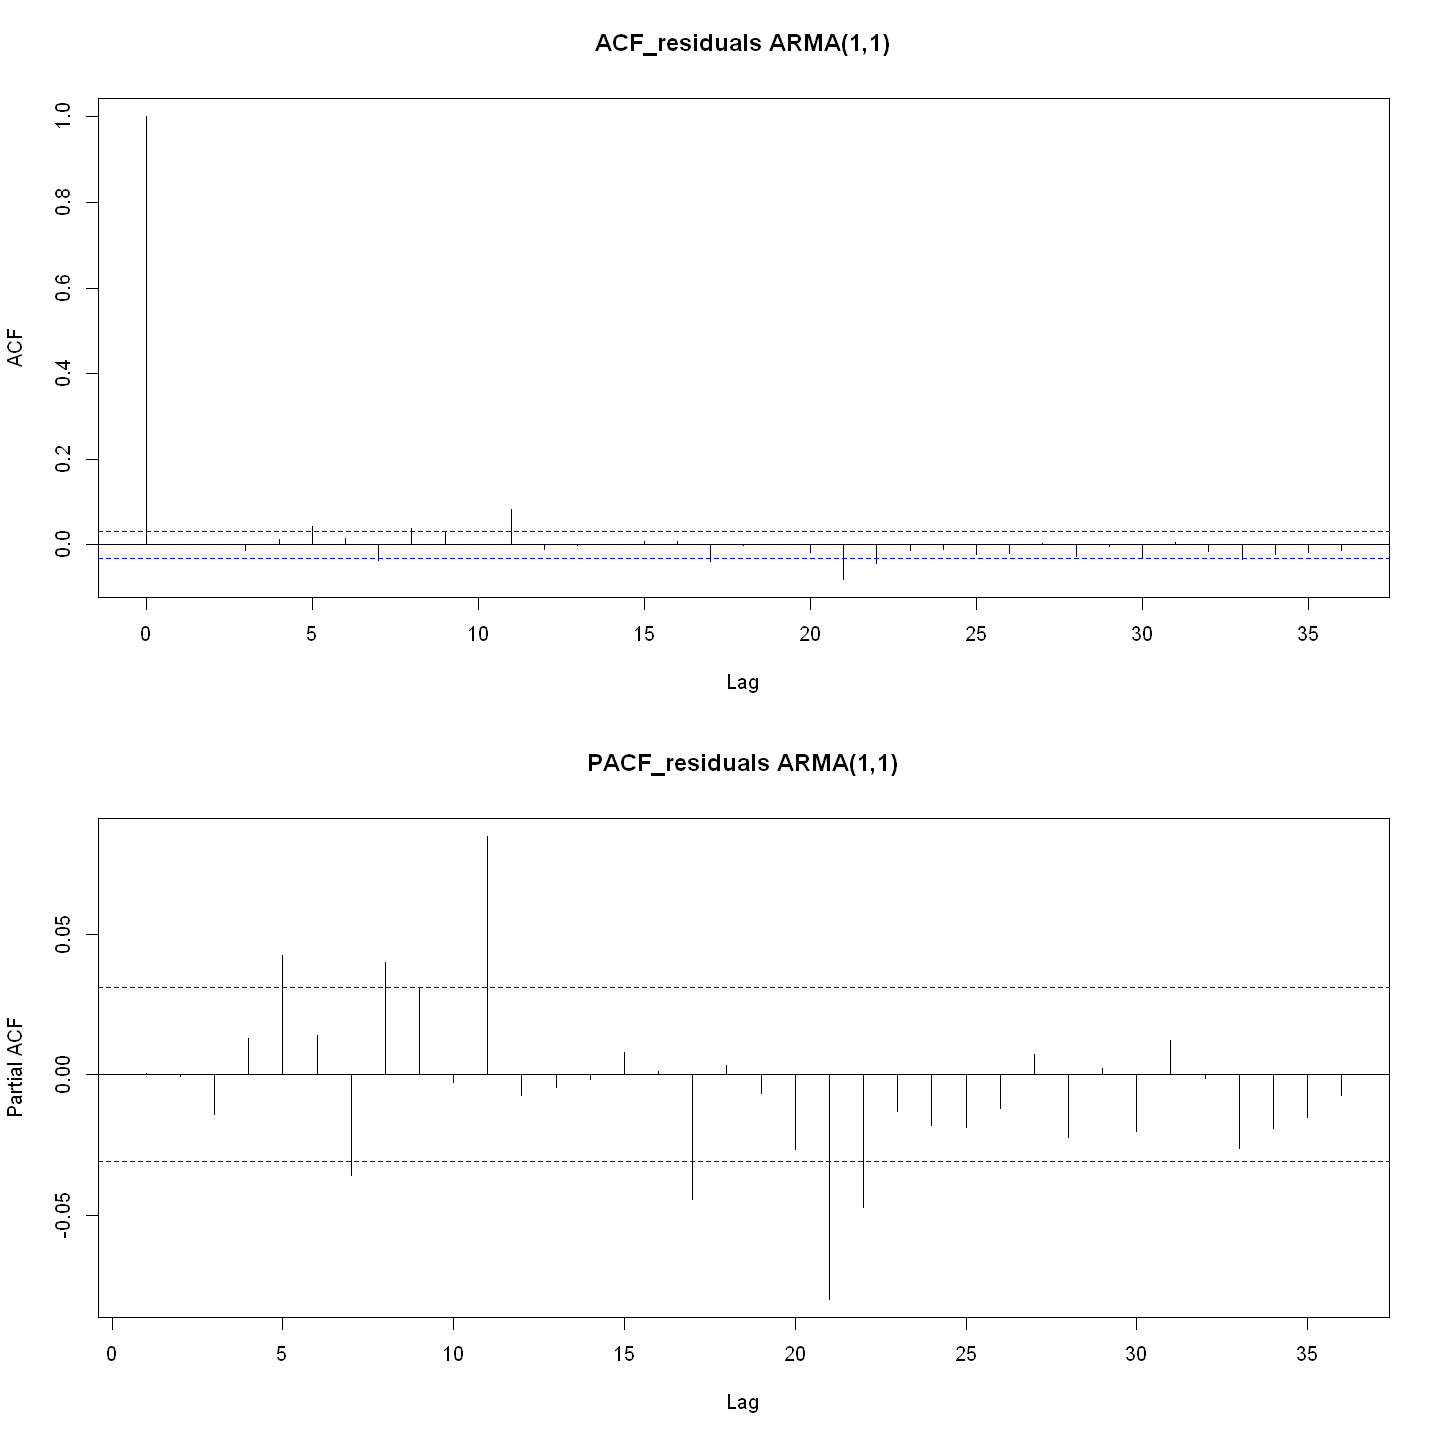

In [19]:
par(mfrow = c(2,1 ))
acf(B_ma1$residuals, main = "ACF_residuals MA(1)")
pacf(B_ma1$residuals, main = "PACF_residuals MA(1)")
acf(B_ar1$residuals, main = "ACF_residuals AR(1)")
pacf(B_ar1$residuals, main = "PACF_residuals AR(1)")
acf(B_arma11$residuals, main = "ACF_residuals ARMA(1,1)")
pacf(B_arma11$residuals, main = "PACF_residuals ARMA(1,1)")

In [20]:
Box.test(B_ma1$residuals, type = "Ljung-Box", lag = 4)
Box.test(B_ma1$residuals, type = "Ljung-Box", lag = 8)
Box.test(B_ma1$residuals, type = "Ljung-Box", lag = 12)
Box.test(B_ar1$residuals, type = "Ljung-Box", lag = 4)
Box.test(B_ar1$residuals, type = "Ljung-Box", lag = 8)
Box.test(B_ar1$residuals, type = "Ljung-Box", lag = 12)
Box.test(B_arma11$residuals, type = "Ljung-Box", lag = 4)
Box.test(B_arma11$residuals, type = "Ljung-Box", lag = 8)
Box.test(B_arma11$residuals, type = "Ljung-Box", lag = 12)


	Box-Ljung test

data:  B_ma1$residuals
X-squared = 5.0612, df = 4, p-value = 0.2811



	Box-Ljung test

data:  B_ma1$residuals
X-squared = 23.872, df = 8, p-value = 0.002408



	Box-Ljung test

data:  B_ma1$residuals
X-squared = 57.346, df = 12, p-value = 6.844e-08



	Box-Ljung test

data:  B_ar1$residuals
X-squared = 3.9309, df = 4, p-value = 0.4154



	Box-Ljung test

data:  B_ar1$residuals
X-squared = 24.252, df = 8, p-value = 0.002079



	Box-Ljung test

data:  B_ar1$residuals
X-squared = 55.97, df = 12, p-value = 1.212e-07



	Box-Ljung test

data:  B_arma11$residuals
X-squared = 1.4527, df = 4, p-value = 0.835



	Box-Ljung test

data:  B_arma11$residuals
X-squared = 20.796, df = 8, p-value = 0.00771



	Box-Ljung test

data:  B_arma11$residuals
X-squared = 53.207, df = 12, p-value = 3.785e-07


In [21]:
models <- 3
criteria <- matrix(ncol = 2, nrow = models)
colnames(criteria) <- c('AIC', 'BIC')
rownames(criteria) <- c('MA(1)','AR(1)' ,'ARMA(1,1)')

criteria[1, 1] <- B_ma1$aic
criteria[1, 2] <- B_ma1$bic
criteria[2, 1] <- B_ar1$aic
criteria[2, 2] <- B_ar1$bic
criteria[3, 1] <- B_arma11$aic
criteria[3, 2] <- B_arma11$bic

criteria

,AIC,BIC
MA(1),-16753.83,-16734.94
AR(1),-16754.96,-16736.08
"ARMA(1,1)",-16755.42,-16730.24


BIC is compensating for the amount of parameter estimates, therefore it gets closer to zero in this case for models with more parameters

Since there is virtually no evidence supporting AR(1) over MA(1) and vice versa we make the decision through information criteria. These favor the **AR(1)** as the most plausible mean model for the **series B**

#### Series C Box-Jenkins

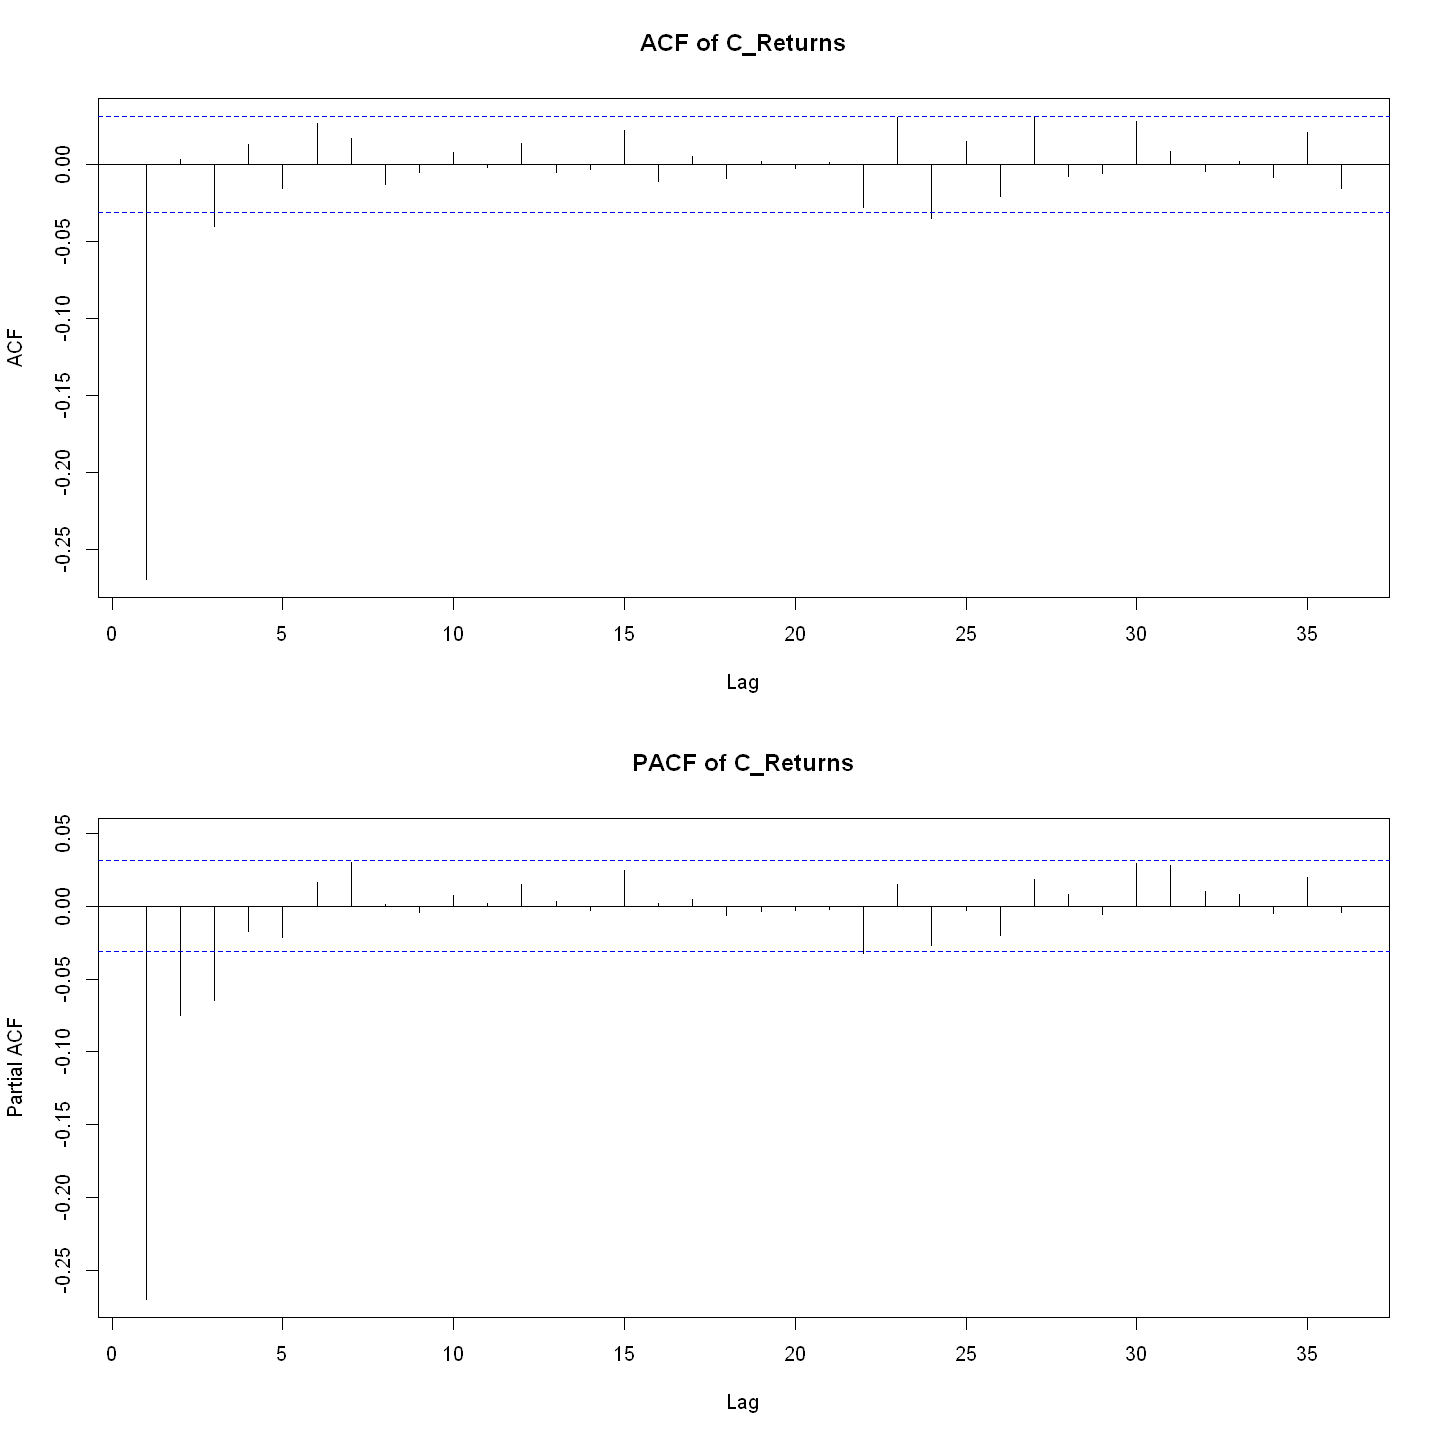

In [22]:
options(repr.plot.width = 12, repr.plot.height = 12)
par(mfrow = c(2, 1))
Acf(series_C$ret, main="ACF of C_Returns")
Pacf(series_C$ret, main="PACF of C_Returns")

Since the **PACF** decays slowly and the **ACF** drops after the first lag we are highly expecting this process to be MA(1) and we add also MA(3) since the third lag in ACF is slightly significant. Lastly we will also estimate ARMA(1,1) as a comparison and to if ARMA specification yields better results.

In [23]:
C_ma3 <- Arima(series_C$ret, order = c(0, 0, 3))
summary(C_ma3)
C_ma1 <- Arima(series_C$ret, order = c(0, 0, 1))
summary(C_ma1)
C_arma11 <- Arima(series_C$ret, order = c(1, 0, 1))
summary(C_arma11)

Series: series_C$ret 
ARIMA(0,0,3) with non-zero mean 

Coefficients:
          ma1      ma2      ma3   mean
      -0.2953  -0.0082  -0.0338  0e+00
s.e.   0.0158   0.0163   0.0153  1e-04

sigma^2 = 0.0001058:  log likelihood = 12634.95
AIC=-25259.9   AICc=-25259.89   BIC=-25228.43

Training set error measures:
                       ME       RMSE         MAE      MPE     MAPE      MASE
Training set 2.160327e-07 0.01027863 0.008110659 109.9061 195.9455 0.6054188
                      ACF1
Training set -0.0005747847

Series: series_C$ret 
ARIMA(0,0,1) with non-zero mean 

Coefficients:
          ma1   mean
      -0.3016  0e+00
s.e.   0.0155  1e-04

sigma^2 = 0.0001059:  log likelihood = 12631.76
AIC=-25257.53   AICc=-25257.52   BIC=-25238.65

Training set error measures:
                       ME       RMSE         MAE      MPE     MAPE      MASE
Training set 2.734403e-07 0.01028682 0.008111785 106.8524 193.9495 0.6055029
                    ACF1
Training set 0.005926602

Series: series_C$ret 
ARIMA(1,0,1) with non-zero mean 

Coefficients:
         ar1      ma1   mean
      0.0754  -0.3713  0e+00
s.e.  0.0554   0.0520  1e-04

sigma^2 = 0.0001058:  log likelihood = 12632.72
AIC=-25257.43   AICc=-25257.42   BIC=-25232.25

Training set error measures:
                       ME       RMSE         MAE      MPE     MAPE      MASE
Training set 1.741883e-06 0.01028437 0.008114591 105.4373 192.3632 0.6057123
                     ACF1
Training set -0.000659122

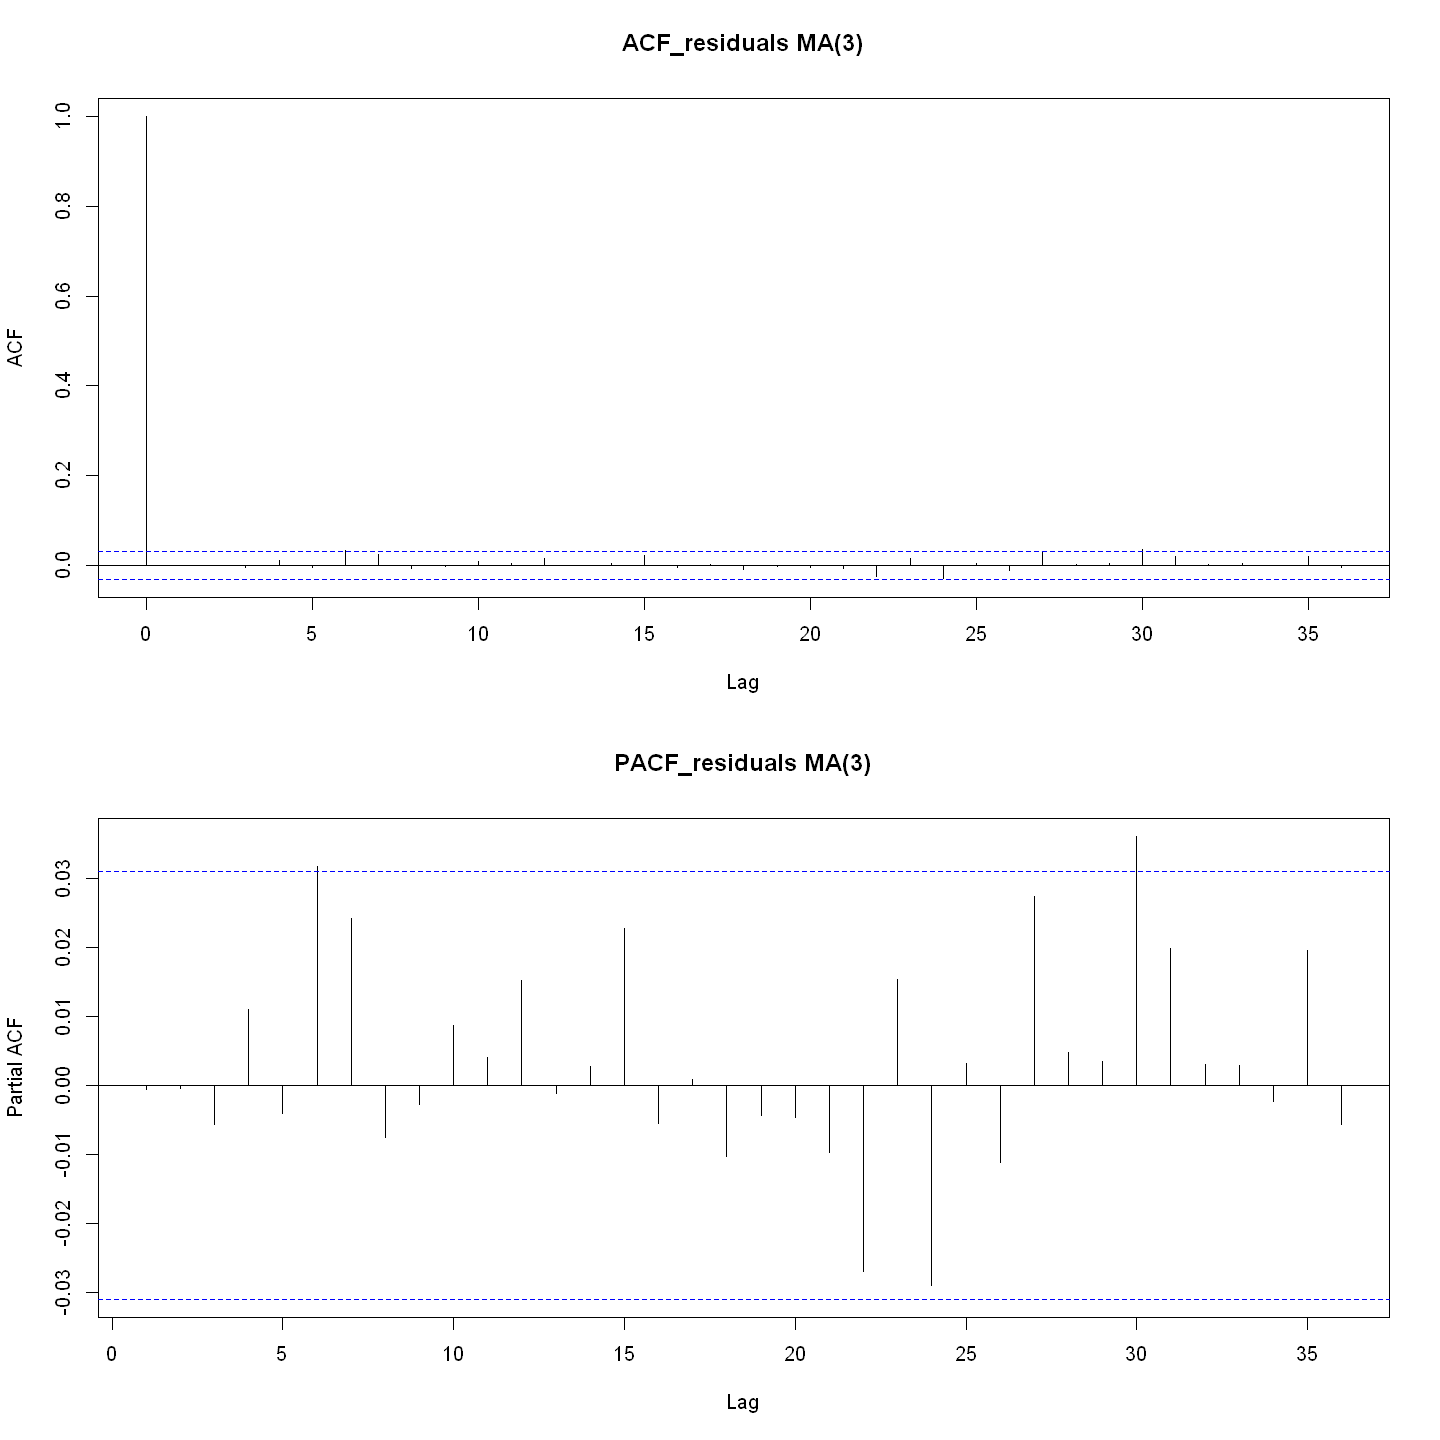

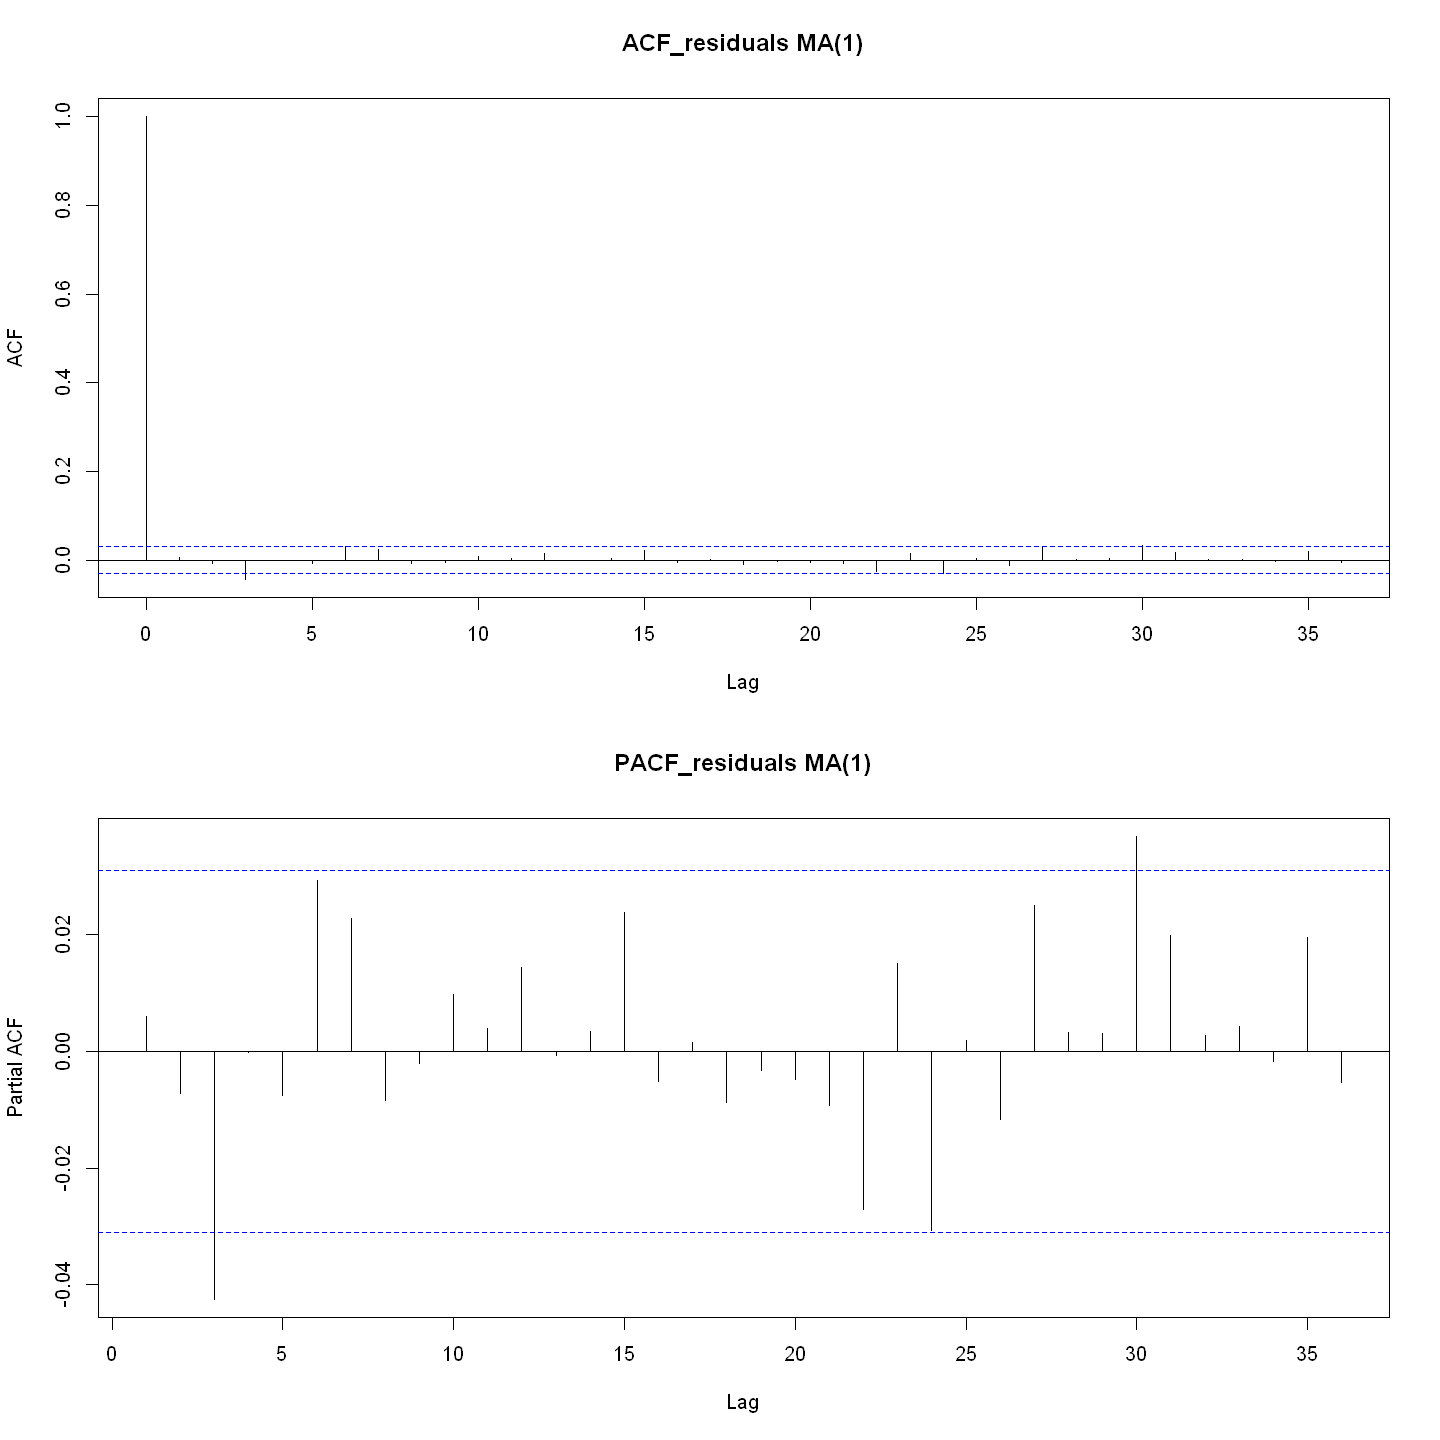

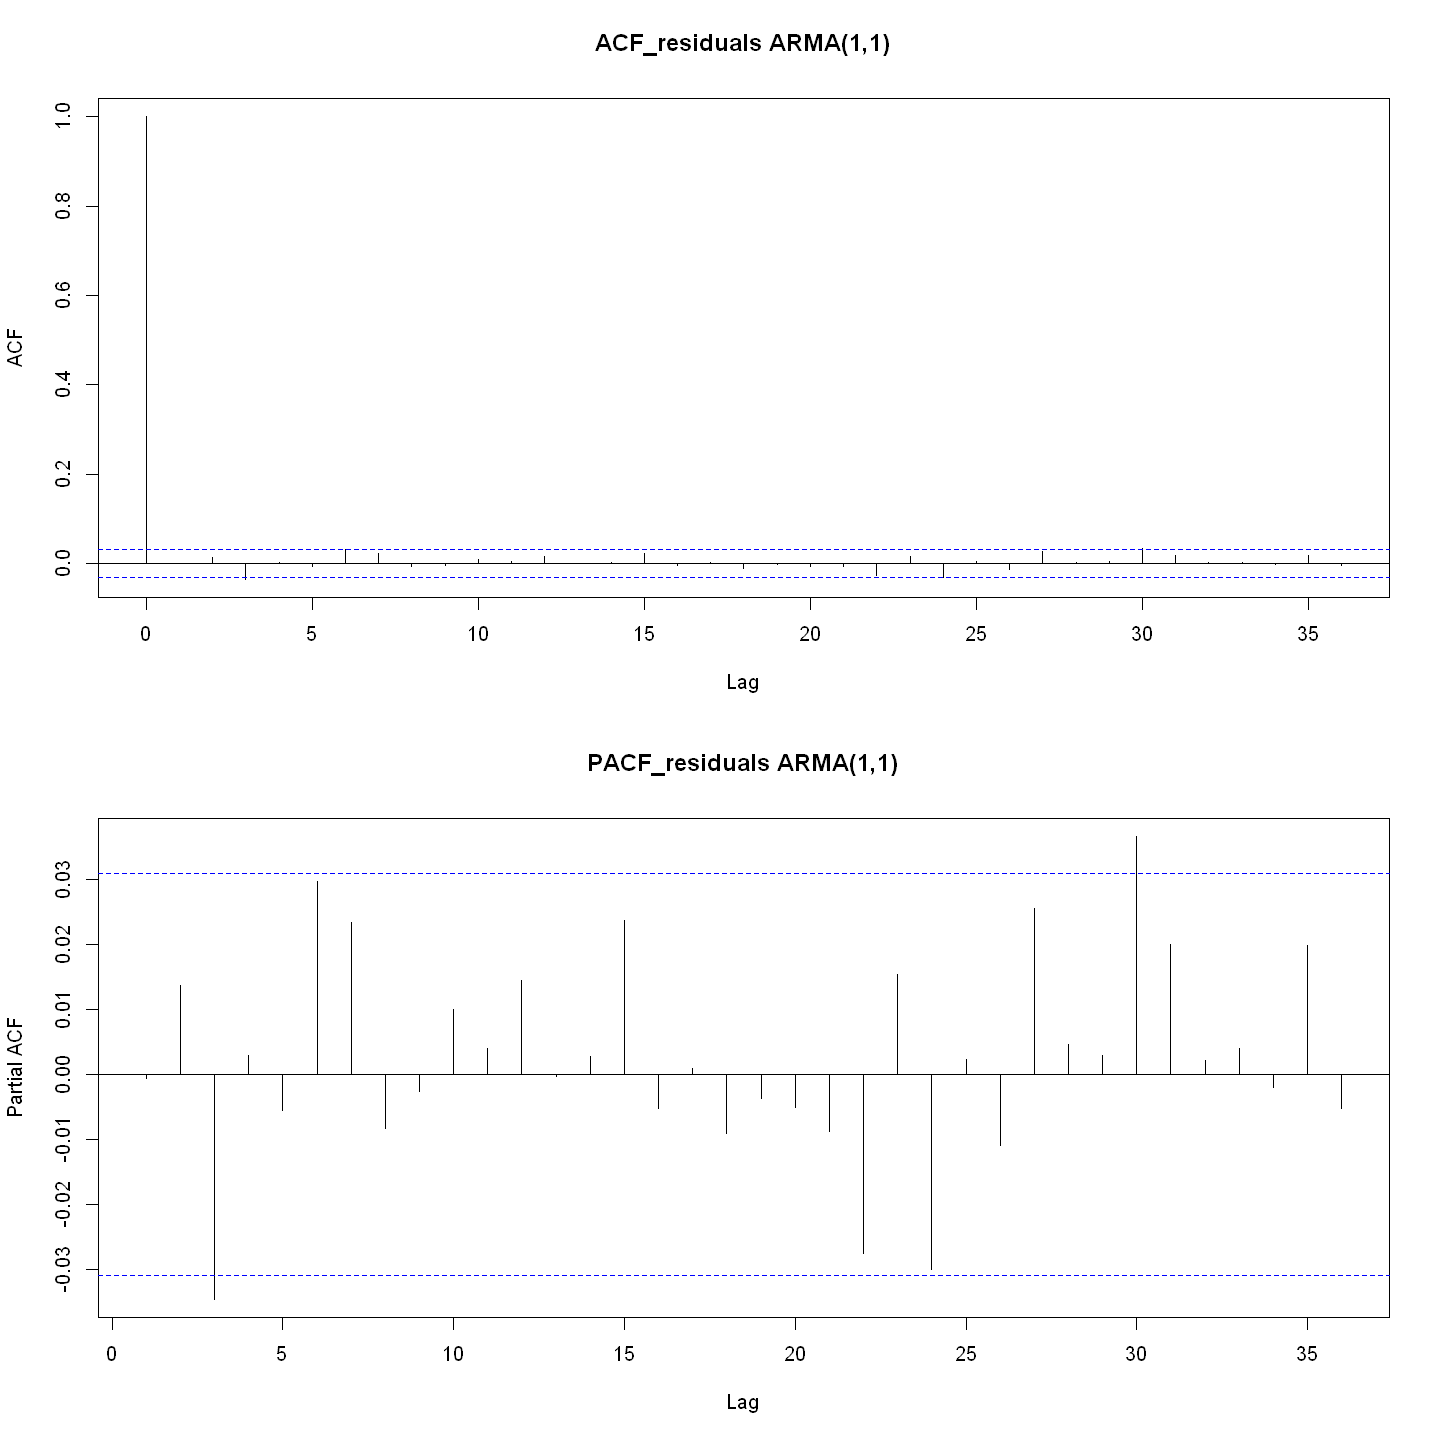

In [24]:
par(mfrow = c(2,1 ))
acf(C_ma3$residuals, main = "ACF_residuals MA(3)")
pacf(C_ma3$residuals, main = "PACF_residuals MA(3)")
acf(C_ma1$residuals, main = "ACF_residuals MA(1)")
pacf(C_ma1$residuals, main = "PACF_residuals MA(1)")
acf(C_arma11$residuals, main = "ACF_residuals ARMA(1,1)")
pacf(C_arma11$residuals, main = "PACF_residuals ARMA(1,1)")

In [25]:
Box.test(C_ma3$residuals, type = "Ljung-Box", lag = 4)
Box.test(C_ma3$residuals, type = "Ljung-Box", lag = 8)
Box.test(C_ma3$residuals, type = "Ljung-Box", lag = 12)
Box.test(C_ma1$residuals, type = "Ljung-Box", lag = 4)
Box.test(C_ma1$residuals, type = "Ljung-Box", lag = 8)
Box.test(C_ma1$residuals, type = "Ljung-Box", lag = 12)
Box.test(C_arma11$residuals, type = "Ljung-Box", lag = 4)
Box.test(C_arma11$residuals, type = "Ljung-Box", lag = 8)
Box.test(C_arma11$residuals, type = "Ljung-Box", lag = 12)


	Box-Ljung test

data:  C_ma3$residuals
X-squared = 0.62123, df = 4, p-value = 0.9607



	Box-Ljung test

data:  C_ma3$residuals
X-squared = 7.2787, df = 8, p-value = 0.5069



	Box-Ljung test

data:  C_ma3$residuals
X-squared = 8.7465, df = 12, p-value = 0.7244



	Box-Ljung test

data:  C_ma1$residuals
X-squared = 7.5989, df = 4, p-value = 0.1074



	Box-Ljung test

data:  C_ma1$residuals
X-squared = 14.077, df = 8, p-value = 0.07978



	Box-Ljung test

data:  C_ma1$residuals
X-squared = 15.421, df = 12, p-value = 0.2192



	Box-Ljung test

data:  C_arma11$residuals
X-squared = 5.5955, df = 4, p-value = 0.2315



	Box-Ljung test

data:  C_arma11$residuals
X-squared = 11.915, df = 8, p-value = 0.155



	Box-Ljung test

data:  C_arma11$residuals
X-squared = 13.292, df = 12, p-value = 0.3482


In [26]:
models <- 3
criteria <- matrix(ncol = 2, nrow = models)
colnames(criteria) <- c('AIC', 'BIC')
rownames(criteria) <- c('MA(3)','MA(1)' ,'ARMA(1,1)')

criteria[1, 1] <- C_ma3$aic
criteria[1, 2] <- C_ma3$bic
criteria[2, 1] <- C_ma1$aic
criteria[2, 2] <- C_ma1$bic
criteria[3, 1] <- C_arma11$aic
criteria[3, 2] <- C_arma11$bic

criteria

,AIC,BIC
MA(3),-25259.90,-25228.43
MA(1),-25257.53,-25238.65
"ARMA(1,1)",-25257.43,-25232.25


BIC is compensating for the amount of parameter estimates, therefore it gets larger for models with more parameters

All three models perform very similarly and therefore we prefer the most simple one, the **MA(1) for series C**

### Problem 3:  Residual diagnostics and ARCH effects

#### Residual diagnostics - Series A

ARCH-LM Test - Series A (AR(2))
─────────────────────────────────
Lags = 5:

	ARCH LM-test; Null hypothesis: no ARCH effects

data:  resid_A
Chi-squared = 8.5816, df = 5, p-value = 0.127

Lags = 10:

	ARCH LM-test; Null hypothesis: no ARCH effects

data:  resid_A
Chi-squared = 9.0278, df = 10, p-value = 0.5295



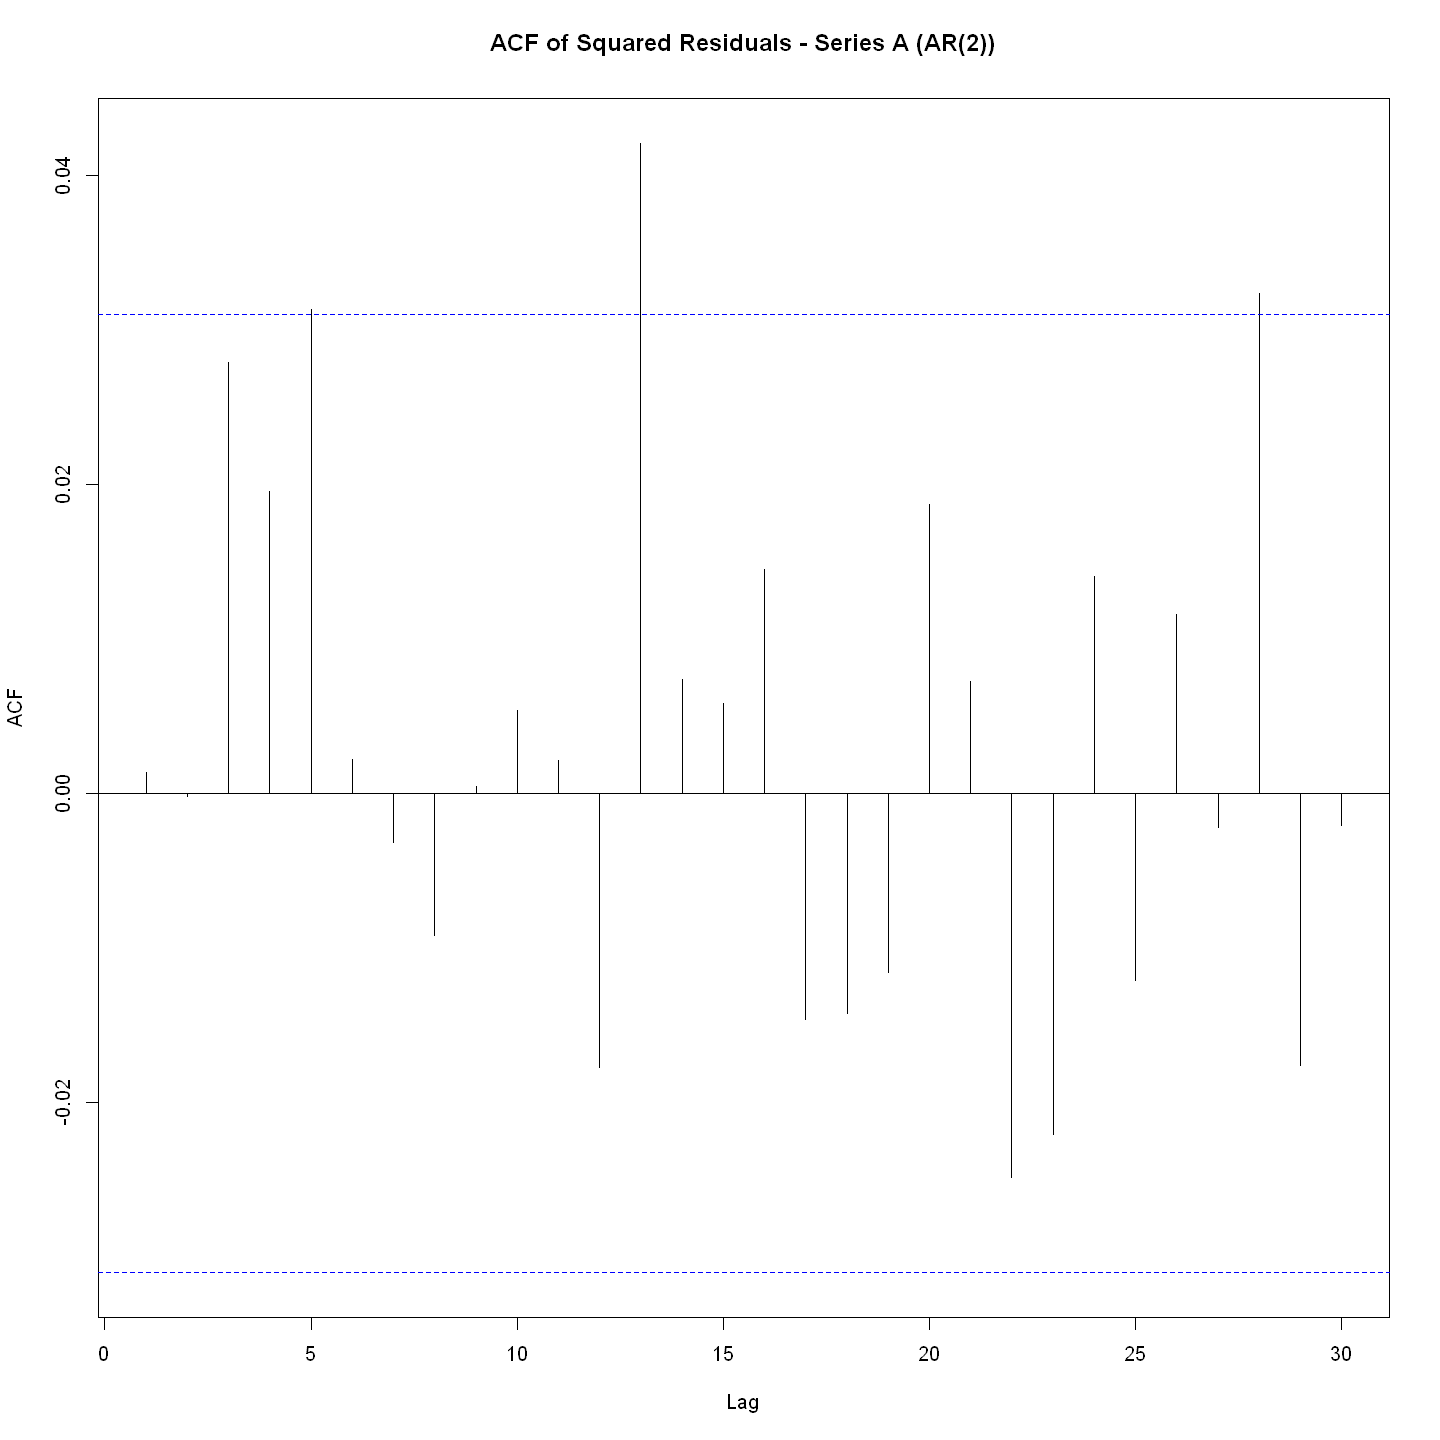

In [27]:
# Extract residuals from the MA(1) model
resid_A <- residuals(A_ar2)

# ACF of squared residuals
par(mfrow = c(1, 1))
Acf(resid_A^2,
    main = "ACF of Squared Residuals - Series A (AR(2))",
    lag.max = 30)

# Test for conditional heteroskedasticity (ARCH-LM test) 
arch_test_A_5  <- ArchTest(resid_A, lags = 5)
arch_test_A_10 <- ArchTest(resid_A, lags = 10)

cat("ARCH-LM Test - Series A (AR(2))\n")
cat("─────────────────────────────────\n")
cat("Lags = 5:\n")
print(arch_test_A_5)
cat("Lags = 10:\n")
print(arch_test_A_10)

The ACF of the squared residuals for Series A shows no significant pattern across the lags. The two marginal spikes at lags 13 and 27 are barely outside the confidence bounds so we do not interpret them as evidence of some unmodelled structure.

The ARCH-LM test fails to reject the null hypohesis of no ARCH effects at both lag 5 (p = 0.11) and lag 10 (p = 0.50). This was expected, as Series A has constant variance throughout the sample so there is no volatility clustering to capture, and an ARCH or GARCH component would bring no improvement.

#### Residual diagnostics - Series B

ARCH-LM Test - Series B (AR(1))
─────────────────────────────────
Lags = 5:

	ARCH LM-test; Null hypothesis: no ARCH effects

data:  resid_B
Chi-squared = 1503.2, df = 5, p-value < 2.2e-16

Lags = 10:

	ARCH LM-test; Null hypothesis: no ARCH effects

data:  resid_B
Chi-squared = 1567.7, df = 10, p-value < 2.2e-16



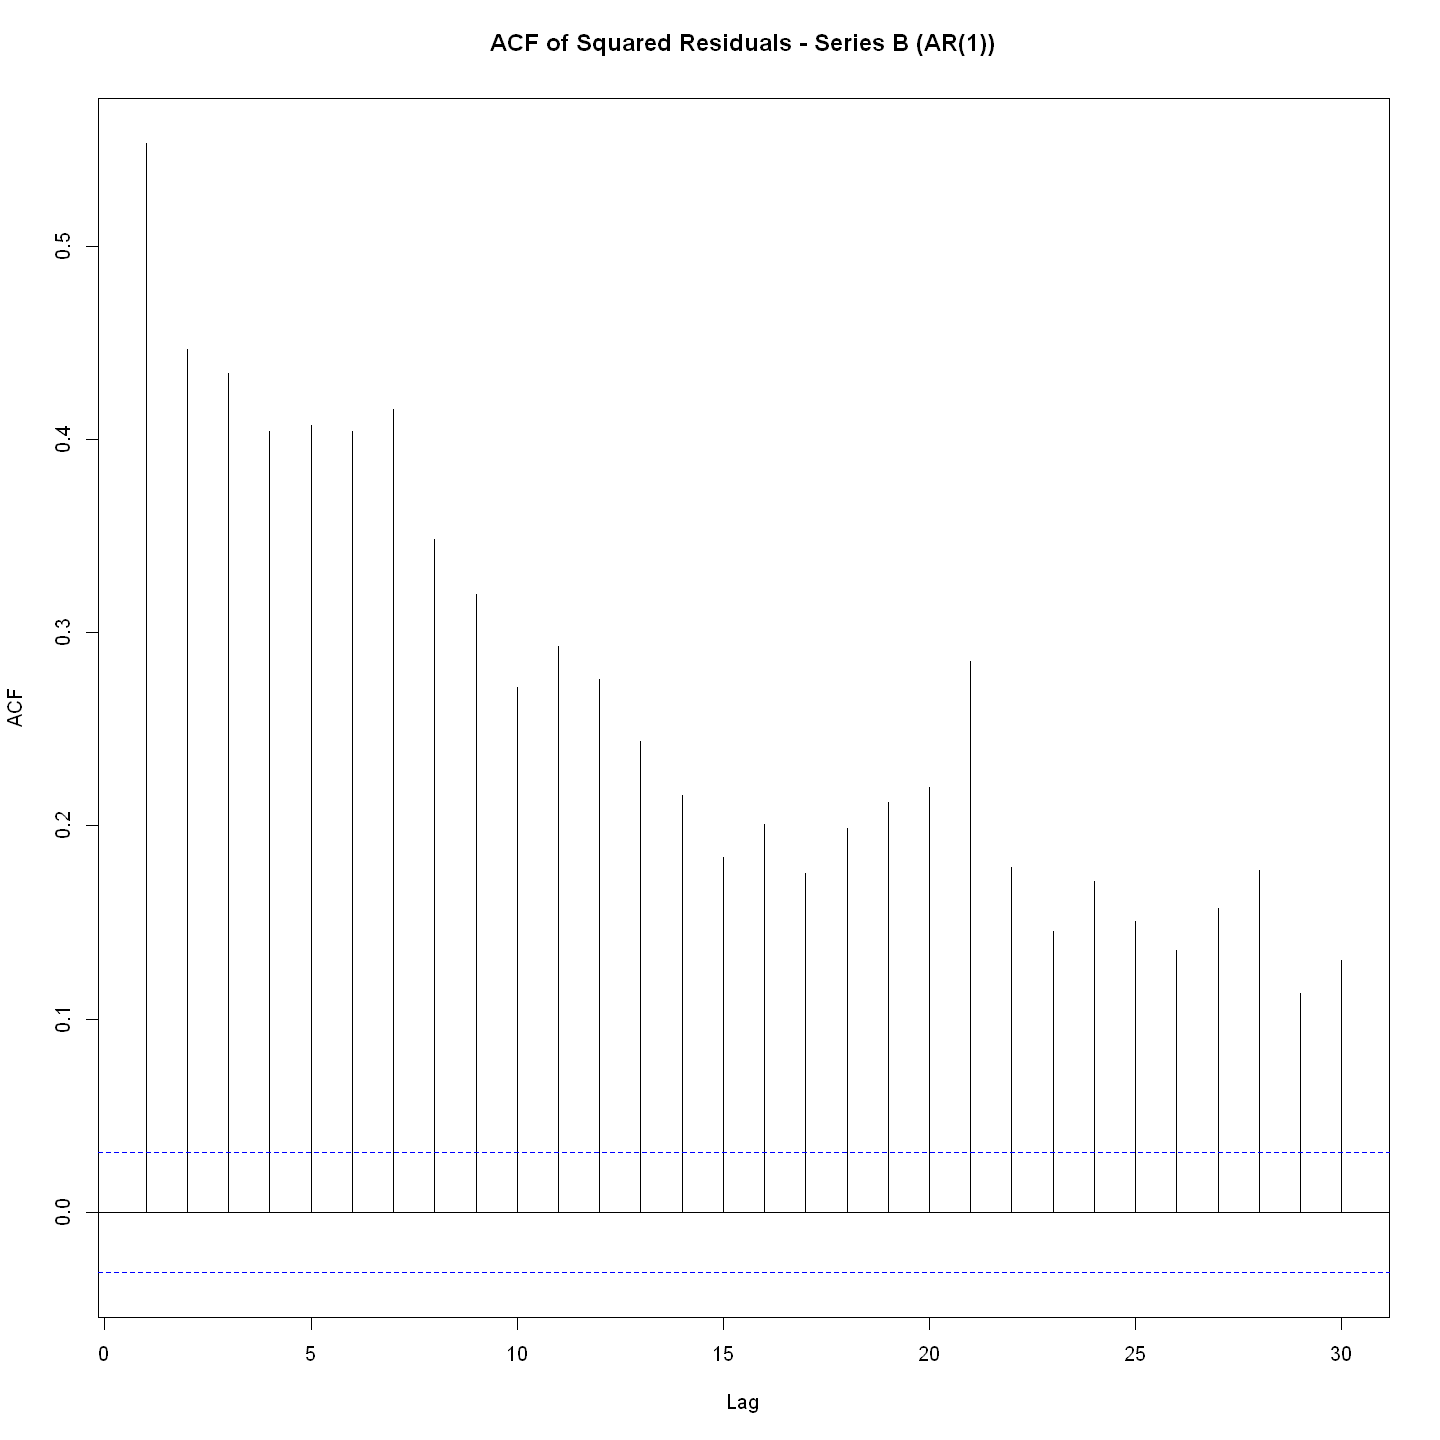

In [28]:
# Extract residuals from the AR(1) model
resid_B <- residuals(B_ma1)

# ACF of squared residuals
par(mfrow = c(1, 1))
Acf(resid_B^2,
    main = "ACF of Squared Residuals - Series B (AR(1))",
    lag.max = 30)

# Test for conditional heteroskedasticity (ARCH-LM test) 
arch_test_B_5  <- ArchTest(resid_B, lags = 5)
arch_test_B_10 <- ArchTest(resid_B, lags = 10)

cat("ARCH-LM Test - Series B (AR(1))\n")
cat("─────────────────────────────────\n")
cat("Lags = 5:\n")
print(arch_test_B_5)
cat("Lags = 10:\n")
print(arch_test_B_10)

The ACF of squared residuals for Series B looks very different from Series A. All lags up to 30 are highly significant and decay slowly, which indicates volatility clustering.

The ARCH-LM test confirms this. The null hypothesis of no ARCH effects is rejected even at the 1% significance level. The AR(1) mean equation is therefore adequate on its own, but ignores the variance dynamics present in the data. Adding a GARCH component would model this time-varying volatility explicitly, producing tighter and more honest confidence intervals around the mean forecasts that are wider during volatile periods and narrower during calm ones.

#### Residual diagnostics - Series C

ARCH-LM Test - Series C (MA(1))
─────────────────────────────────
Lags = 5:

	ARCH LM-test; Null hypothesis: no ARCH effects

data:  resid_C
Chi-squared = 231.13, df = 5, p-value < 2.2e-16

Lags = 10:

	ARCH LM-test; Null hypothesis: no ARCH effects

data:  resid_C
Chi-squared = 236.7, df = 10, p-value < 2.2e-16



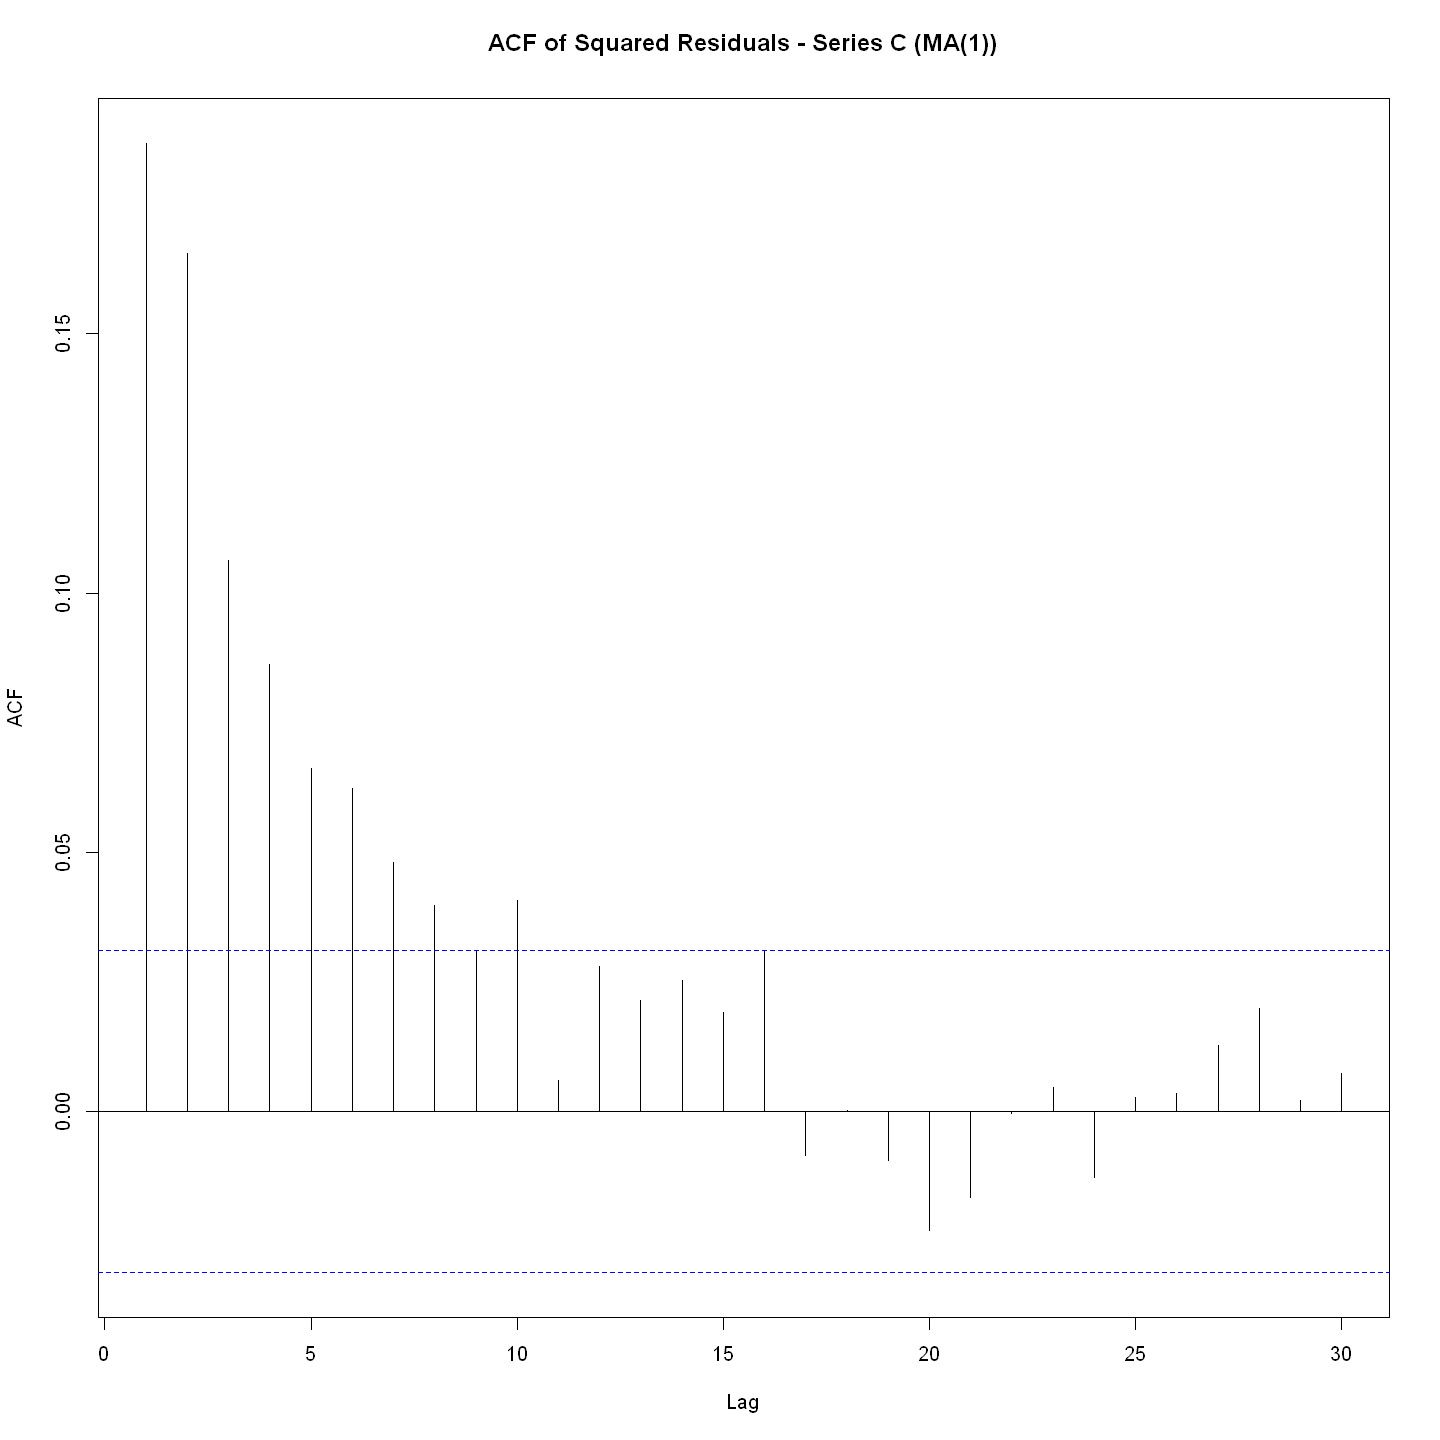

In [29]:
# Extract residuals from the MA(1) model
resid_C <- residuals(C_ma1)

# ACF of squared residuals
par(mfrow = c(1, 1))
Acf(resid_C^2,
    main = "ACF of Squared Residuals - Series C (MA(1))",
    lag.max = 30)

# Test for conditional heteroskedasticity (ARCH-LM test) 
arch_test_C_5  <- ArchTest(resid_C, lags = 5)
arch_test_C_10 <- ArchTest(resid_C, lags = 10)

cat("ARCH-LM Test - Series C (MA(1))\n")
cat("─────────────────────────────────\n")
cat("Lags = 5:\n")
print(arch_test_C_5)
cat("Lags = 10:\n")
print(arch_test_C_10)

The ACF of squared residuals for Series C shows a similar pattern to Series B, but less pronounced. Significant lags are present up to around lag 10, with smaller magnitudes and faster decay than in Series B. This still indicates clear volatility clustering, but the effects are less persistent. Once a shock occurs, variance returns to its average level more quickly.

The ARCH LM-test confirms this. The null of no ARCH effects is rejected even at the 1% significance level. A GARCH component is therefore needed, but we would expect lower persistence (a smaller beta) compared to Series B.

### Problem 4: Modeling conditional volatility

We now proceed to estimate a GARCH(1,1) model for each of the series, using the selected ARMA structure to model the mean. 

#### GARCH Modeling -- Series A

For Series A, we have selected MA(1) as the mean model, so the GARCH specification will be as follows:

In [36]:
A_garch_spec <- ugarchspec(
    mean.model = list(armaOrder = c(0, 1), include.mean = TRUE),
    variance.model = list(model = "sGARCH", garchOrder = c(1, 1))
)

A_garch <- ugarchfit(spec = A_garch_spec, data = series_A$ret)

show(A_garch)


*---------------------------------*
*          GARCH Model Fit        *
*---------------------------------*

Conditional Variance Dynamics 	
-----------------------------------
GARCH Model	: sGARCH(1,1)
Mean Model	: ARFIMA(0,0,1)
Distribution	: norm 

Optimal Parameters
------------------------------------
        Estimate  Std. Error     t value Pr(>|t|)
mu      0.000083    0.000109     0.75845  0.44818
ma1    -0.312529    0.014537   -21.49866  0.00000
omega   0.000000    0.000000     0.72985  0.46548
alpha1  0.001854    0.000277     6.69774  0.00000
beta1   0.995447    0.000066 15048.72508  0.00000

Robust Standard Errors:
        Estimate  Std. Error     t value Pr(>|t|)
mu      0.000083    0.000115    0.717732  0.47292
ma1    -0.312529    0.017037  -18.344404  0.00000
omega   0.000000    0.000013    0.021098  0.98317
alpha1  0.001854    0.010459    0.177312  0.85926
beta1   0.995447    0.000615 1618.832502  0.00000

LogLikelihood : 12729.23 

Information Criteria
-----------------

Interpreting the results for Series A using robust SEs, we observe that the coefficients take on quite extreme values: $\omega = 0$, statistically insignificant; $\alpha_1 \approx 0.0019$, statistically insignificant; and $\beta_1 \approx 0.9954$, statistically significant.

What we have here is a case of trying to apply heteroskedasticity modelling to a homoscedastic dataset. In Problem 1, we saw that Series A has a constant variance, which fully manifests in our model results. The parameter $\alpha_1$ (persistence of shocks) is small and insignificant, basically zero with some noise - this means that yesterday's shocks do not influence future volatility. The parameter $\beta_1$ (persistence of variance) is almost one and the parameter $\omega$ is zero - this fundamentally means that the model has encountered the constant variance of Series A, and interpeted it as the baseline being zero and todays variance being essentially equal to yesterday's variance.

Theoretically, the persistence measure of the volatility in Series A would be $\alpha_1 + \beta_1 \approx 0.0019 + 0.9954 = 0.9973$ - but in the case of a homoscedastic series, the interpretation of this measure is distorted. In using it, we should aim to measure the persistence of volatility clusters - however, there are none to speak of in this series.

#### GARCH Modeling - Series B

For Series B, we have selected AR(1) as the mean model, so the GARCH specification will be as follows:

In [ ]:
B_garch_spec <- ugarchspec(
    mean.model = list(armaOrder = c(1, 0), include.mean = TRUE),
    variance.model = list(model = "sGARCH", garchOrder = c(1, 1))
)

B_garch <- ugarchfit(spec = B_garch_spec, data = series_B$ret)

show(B_garch)


*---------------------------------*
*          GARCH Model Fit        *
*---------------------------------*

Conditional Variance Dynamics 	
-----------------------------------
GARCH Model	: sGARCH(1,1)
Mean Model	: ARFIMA(1,0,0)
Distribution	: norm 

Optimal Parameters
------------------------------------
        Estimate  Std. Error   t value Pr(>|t|)
mu      0.000146    0.000238   0.61039   0.5416
ar1    -0.256304    0.016127 -15.89264   0.0000
omega   0.000021    0.000003   6.21650   0.0000
alpha1  0.193025    0.014577  13.24133   0.0000
beta1   0.783640    0.014459  54.19596   0.0000

Robust Standard Errors:
        Estimate  Std. Error   t value Pr(>|t|)
mu      0.000146    0.000219   0.66341  0.50707
ar1    -0.256304    0.015633 -16.39504  0.00000
omega   0.000021    0.000003   6.65642  0.00000
alpha1  0.193025    0.013901  13.88550  0.00000
beta1   0.783640    0.013236  59.20691  0.00000

LogLikelihood : 9366.159 

Information Criteria
------------------------------------
    

With Series B, we observe a completely different picture than with Series A. $\alpha_1 \approx 0.1930$, $\beta_1 \approx 0.7836$, and $\omega \approx 0.000021$. All three coefficients are statistically significant.

Here, we have a heteroscedastic series with genuine ARCH effects. Interpreting the parameters, the value of $\alpha_1$ indicates that about 19.3 % of yesterday's shock is directly incorporated into today's volatility. In the event of a shock, the value of $\beta_1$ implies that this volatility has a considerable memory - about 78.36 % of yesterday's variance carries over to the variance of today. 

The persistence measure equals $\alpha_1 + \beta_1 \approx 0.1930 + 0.7836 = 0.9766$. This value, which is very clsoe to one, implies a very high persistence of volatility, as suggested by the squared residual ACF plot in Problem 3. However, it is still less than one - implying that the volatility is stationary, and will eventually revert back to its baseline level $\omega$.

#### GARCH Modeling - Series C

For Series C, we have selected MA(1) as the mean model, so the GARCH specification will be as follows:

In [35]:
C_garch_spec <- ugarchspec(
    mean.model = list(armaOrder = c(0, 1), include.mean = TRUE),
    variance.model = list(model = "sGARCH", garchOrder = c(1, 1))
)

C_garch <- ugarchfit(spec = C_garch_spec, data = series_C$ret)

show(C_garch)


*---------------------------------*
*          GARCH Model Fit        *
*---------------------------------*

Conditional Variance Dynamics 	
-----------------------------------
GARCH Model	: sGARCH(1,1)
Mean Model	: ARFIMA(0,0,1)
Distribution	: norm 

Optimal Parameters
------------------------------------
        Estimate  Std. Error   t value Pr(>|t|)
mu      0.000089    0.000105   0.84322  0.39911
ma1    -0.302998    0.016251 -18.64481  0.00000
omega   0.000021    0.000004   5.33017  0.00000
alpha1  0.157340    0.020258   7.76673  0.00000
beta1   0.643724    0.050487  12.75034  0.00000

Robust Standard Errors:
        Estimate  Std. Error   t value Pr(>|t|)
mu      0.000089    0.000110   0.80657 0.419915
ma1    -0.302998    0.015584 -19.44322 0.000000
omega   0.000021    0.000004   4.92224 0.000001
alpha1  0.157340    0.021413   7.34791 0.000000
beta1   0.643724    0.055227  11.65606 0.000000

LogLikelihood : 12739.91 

Information Criteria
------------------------------------
    

Analyzing the results for Series C, we observe another valid case of conditional heteroskedasticity, but with notably different dynamics compared to Series B. $\alpha_1 \approx 0.1573$, $\beta_1 \approx 0.6437$, and $\omega \approx 0.000021$. All three coefficients are statistically significant.

These parameters have the same numerical interpretation as in the above case of Series B. The persistence measure comes out to $\alpha_1 + \beta_1 \approx 0.1573 + 0.6437 = 0.8010$. This means that Series C is still highly persistent, but volatility clusters die out faster than with Series B. 

#### Plotting conditional variance

Let us now plot the conditional variance as follows:

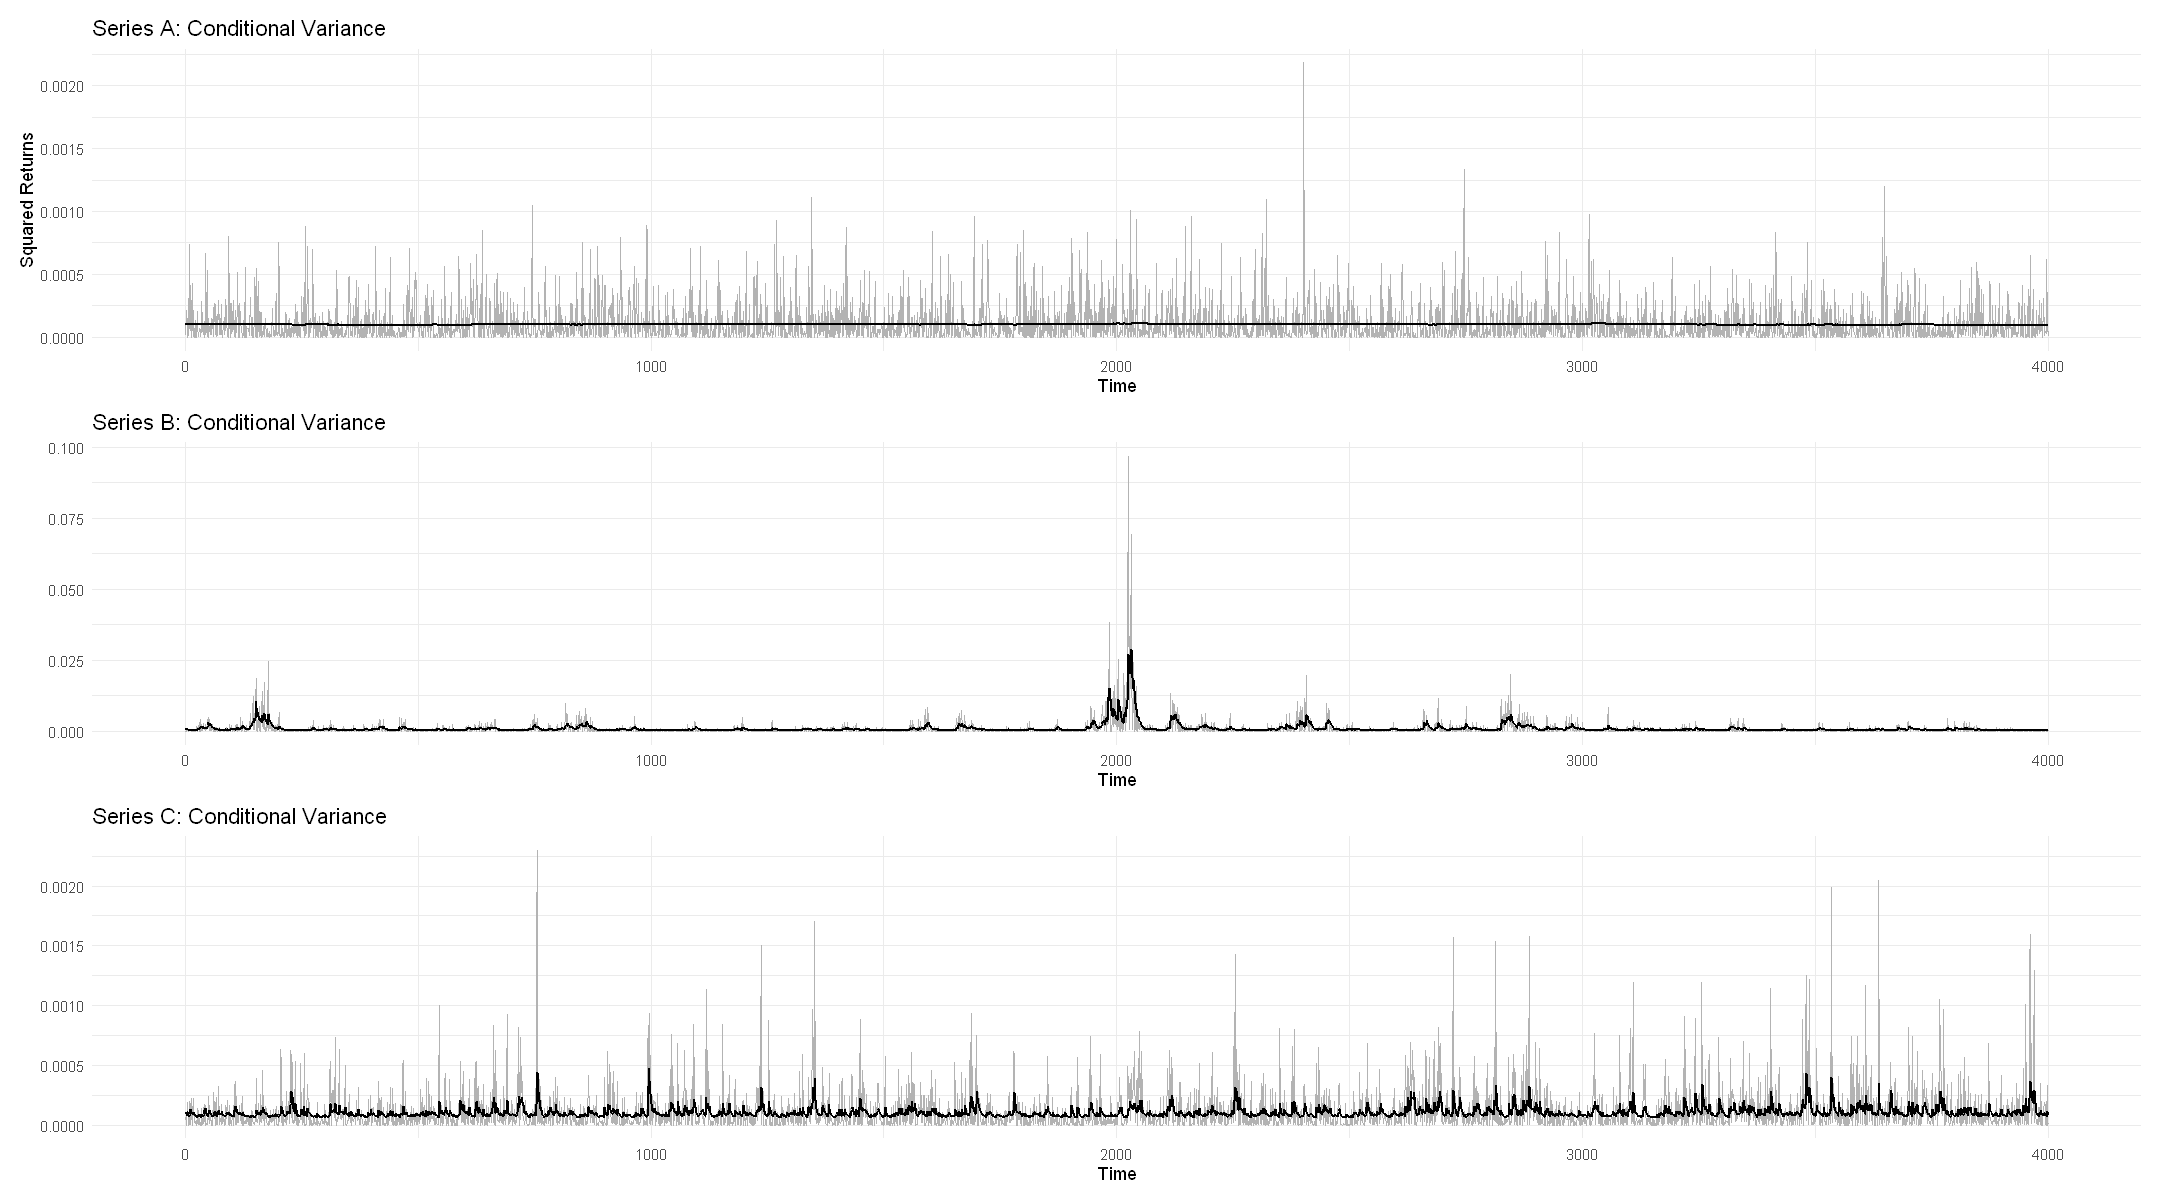

In [41]:

# get conditional variance
cond_var_A <- as.numeric(sigma(A_garch)^2)
cond_var_B <- as.numeric(sigma(B_garch)^2)
cond_var_C <- as.numeric(sigma(C_garch)^2)

# 2. build dfs
df_A <- data.frame(t = seq_along(series_A$ret), sq_ret = series_A$ret^2, cond_var = cond_var_A)
df_B <- data.frame(t = seq_along(series_B$ret), sq_ret = series_B$ret^2, cond_var = cond_var_B)
df_C <- data.frame(t = seq_along(series_C$ret), sq_ret = series_C$ret^2, cond_var = cond_var_C)

# lets get plotting :)
pA <- ggplot(df_A, aes(x = t)) +
  geom_line(aes(y = sq_ret), color = "gray70", linewidth = 0.4) +  
  geom_line(aes(y = cond_var), color = "black", linewidth = 0.8) +  
  labs(title = "Series A: Conditional Variance", x = "Time", y = "Squared Returns") +
  theme_minimal()

pB <- ggplot(df_B, aes(x = t)) +
  geom_line(aes(y = sq_ret), color = "gray70", linewidth = 0.4) +
  geom_line(aes(y = cond_var), color = "black", linewidth = 0.8) +
  labs(title = "Series B: Conditional Variance", x = "Time", y = "") +
  theme_minimal()

pC <- ggplot(df_C, aes(x = t)) +
  geom_line(aes(y = sq_ret), color = "gray70", linewidth = 0.4) +
  geom_line(aes(y = cond_var), color = "black", linewidth = 0.8) +
  labs(title = "Series C: Conditional Variance", x = "Time", y = "") +
  theme_minimal()

options(repr.plot.width = 18, repr.plot.height = 10)
pA / pB / pC

Examining the fitted conditional variance, we can see that Series A is indeed homoskedastic. Its variance is a flat, horizontal line and there is no apparent cluster-like structure in the squared returns data. In contrast, both Series B and C exhibit persistent volatility clustering. It seems that the fitted conditional variance corresponds well with the data, as predicted volatility clusters coincide with periods of elevated volatility in our data.

Comparing the two series, their volatility dynamics differ significantly in their persistence. It is quite clear that the volatility clusters present in Series B persist longer than those present in Series C - be it the massive volatility spike around $t = 2000$ or the other, smaller clusters. This is due to the near-unit persistence of volatility in Series B

While volatility clusters in Series C occur more frequently than in Series B, they are much more brief - aligning with the lower calculated persistency measure. 

#### Comparing volatility persistence

Based on the $\alpha_1$ and $\beta_1$ values, along with a visual inspection of the fitted conditional volatility, we conclude that the volatility clusters in Series B are the most persistent, followed by Series C, which also exhibits volatility clustering, but not of such magnitude. Furthermore, we find that Series A is likely homoskedastic, and thus contains no GARCH effects at all. 

# Problem 5

## Subtask 1: ranking the datasets based on volatility persistence

This subtask has been already discussed in the previous paragraph

## Subtask 2

no GARCH effects: Series A\
medium persistence: Series C\
high persistence: Series B

## Subtask 3

**The estimated parameters:**\
**Series A:** In Problem 3, the ARCH-LM test on the residuals of the chosen mean model failed to reject the null hypothesis of no ARCH effects at any conventional significance level (p-value = 0.127 for 5 lags, and p-value = 0.5295 for 10 lags). This statistical evidence proves the series is homoskedastic, meaning the variance is constant and there are no GARCH parameters to estimate.\
**Series B:** The estimated GARCH(1,1) parameters are strongly significant. We obtained an ARCH term of $\alpha_1 \approx 0.1930$ and a GARCH term of $\beta_1 \approx 0.7836$. Their sum is $0.9766$, which is extremely close to 1. This parameter configuration mathematically indicates a highly persistent volatility process.\
**Series C:** The estimated parameters are also statistically significant but yield a notably lower sum. With $\alpha_1 \approx 0.1573$ and $\beta_1 \approx 0.6437$, the persistence measure is exactly $0.8010$. While this still shows a strong memory of past variance, it is significantly lower than Series B, classifying it as medium persistence.

**The behavior of conditional volatility (from the Problem 4 plots):**\
**Series A:** The conditional volatility plot is simply a flat, horizontal line at $\approx 0.0001$. Because there are no ARCH/GARCH effects, past returns do not conditionally influence today's variance.\
**Series B:** The conditional variance plot shows that once the massive shock hits, the variance remains heavily elevated and decays at an incredibly slow rate. This is because the $\beta_1$ parameter (0.7836) heavily weights yesterday's variance, causing the shock to have a "long memory."\
**Series C:** The conditional variance clearly reacts to shocks (spikes in the plot), but these spikes settle down and revert back to the unconditional mean much more rapidly than in Series B. The lower $\beta_1$ parameter means the process "forgets" the shock more quickly.

**The appearance of volatility clustering in the data (from the Problem 1 plots):**\
**Series A:** The plot of squared returns shows no apparent patterns. Spikes are scattered randomly across the timeline without clumping together, which visualizes the lack of volatility clustering.\
**Series B:** The squared returns plot reveals a massive, dominant cluster around $t=2000$. The visual magnitude of this cluster heavily overshadows the rest of the sample, and the heightened volatility clearly lingers for hundreds of observations before calming down.\
**Series C:** The squared returns plot displays multiple, distinct periods of higher and lower volatility scattered throughout the sample. However, the clusters are smaller and fade out relatively quickly, confirming the presence of clustering but at a "medium" level compared to B.

## Subtask 4

In a GARCH(1,1) model, the persistence of a volatility shock is governed by the sum $\alpha_1 + \beta_1$. This sum determines the decay rate at which the conditional variance mean-reverts to the unconditional (long-run) variance level ($\frac{\omega}{1 - \alpha_1 - \beta_1}$).\
**High Persistence ($\alpha_1 + \beta_1 \to 1$):** When the sum is very close to 1 (as in Series B's 0.9766), the decay rate is extremely slow. This results in a very long "half-life" for volatility shocks, meaning a large shock today will keep the conditional variance elevated for many periods into the future.\
**Lower/Medium Persistence:** When the sum is noticeably less than 1 (as in Series C's 0.8010), the mean-reverting pull is stronger. The system absorbs the shock but "forgets" it more rapidly. The half-life of the shock is shorter, causing the volatility to decay back to its baseline much faster.\
**Zero Persistence:** If there are no GARCH effects (Series A), past shocks convey zero information about future variance, meaning the decay is effectively instantaneous as variance remains completely constant.

### Problem 6: Joint mean and volatility modelling

Now we go on to compare the ARMA models (conditional mean) estimated in Problem 2 with the GARCH models (conditional mean and variance) we built in Problem 4.

#### Conditional mean estimates

Even when faced with heteroskedasticity, the mean parameters should be consistent - so we do not expect them to change when we account for volatility clustering. 

Standard errors might change if the series is heteroskedastic, as the model could become more efficient by accounting for changes in volatility and becomes "more confident" in its mean parameter estimates. 

If the series is homoskedastic, there are no efficiency gains from accounting for heteroskedasticity, as variance is constant - therefore, we should not observe differing standard errors in this case.

In [46]:
print("Series A")
coefficients(A_ma1)
summary(A_ma1)
show(A_garch)



[1] "Series A"


ma1     intercept 
-3.012132e-01  8.355208e-05

Series: series_A$ret 
ARIMA(0,0,1) with non-zero mean 

Coefficients:
          ma1   mean
      -0.3012  1e-04
s.e.   0.0147  1e-04

sigma^2 = 0.0001008:  log likelihood = 12729.8
AIC=-25453.59   AICc=-25453.59   BIC=-25434.71

Training set error measures:
                        ME       RMSE        MAE      MPE     MAPE      MASE
Training set -4.622998e-08 0.01003778 0.00798011 106.2978 207.3473 0.5986774
                    ACF1
Training set -0.00296057


*---------------------------------*
*          GARCH Model Fit        *
*---------------------------------*

Conditional Variance Dynamics 	
-----------------------------------
GARCH Model	: sGARCH(1,1)
Mean Model	: ARFIMA(0,0,1)
Distribution	: norm 

Optimal Parameters
------------------------------------
        Estimate  Std. Error     t value Pr(>|t|)
mu      0.000083    0.000109     0.75845  0.44818
ma1    -0.312529    0.014537   -21.49866  0.00000
omega   0.000000    0.000000     0.72985  0.46548
alpha1  0.001854    0.000277     6.69774  0.00000
beta1   0.995447    0.000066 15048.72508  0.00000

Robust Standard Errors:
        Estimate  Std. Error     t value Pr(>|t|)
mu      0.000083    0.000115    0.717732  0.47292
ma1    -0.312529    0.017037  -18.344404  0.00000
omega   0.000000    0.000013    0.021098  0.98317
alpha1  0.001854    0.010459    0.177312  0.85926
beta1   0.995447    0.000615 1618.832502  0.00000

LogLikelihood : 12729.23 

Information Criteria
-----------------

In [47]:
print("Series B")
coefficients(B_ar1)
summary(B_ar1)
show(B_garch)

[1] "Series B"


ar1    intercept 
-2.35789e-01 -1.49166e-05

Series: series_B$ret 
ARIMA(1,0,0) with non-zero mean 

Coefficients:
          ar1   mean
      -0.2358  0e+00
s.e.   0.0154  4e-04

sigma^2 = 0.000887:  log likelihood = 8380.48
AIC=-16754.96   AICc=-16754.95   BIC=-16736.08

Training set error measures:
                       ME       RMSE        MAE      MPE     MAPE      MASE
Training set 2.027819e-07 0.02977561 0.02070193 170.3504 275.6803 0.6234501
                     ACF1
Training set -0.005487077


*---------------------------------*
*          GARCH Model Fit        *
*---------------------------------*

Conditional Variance Dynamics 	
-----------------------------------
GARCH Model	: sGARCH(1,1)
Mean Model	: ARFIMA(1,0,0)
Distribution	: norm 

Optimal Parameters
------------------------------------
        Estimate  Std. Error   t value Pr(>|t|)
mu      0.000146    0.000238   0.61039   0.5416
ar1    -0.256304    0.016127 -15.89264   0.0000
omega   0.000021    0.000003   6.21650   0.0000
alpha1  0.193025    0.014577  13.24133   0.0000
beta1   0.783640    0.014459  54.19596   0.0000

Robust Standard Errors:
        Estimate  Std. Error   t value Pr(>|t|)
mu      0.000146    0.000219   0.66341  0.50707
ar1    -0.256304    0.015633 -16.39504  0.00000
omega   0.000021    0.000003   6.65642  0.00000
alpha1  0.193025    0.013901  13.88550  0.00000
beta1   0.783640    0.013236  59.20691  0.00000

LogLikelihood : 9366.159 

Information Criteria
------------------------------------
    

In [48]:
print("Series C")
coefficients(C_ma1)
summary(C_ma1)
show(C_garch)

[1] "Series C"


ma1     intercept 
-3.016023e-01  1.561847e-05

Series: series_C$ret 
ARIMA(0,0,1) with non-zero mean 

Coefficients:
          ma1   mean
      -0.3016  0e+00
s.e.   0.0155  1e-04

sigma^2 = 0.0001059:  log likelihood = 12631.76
AIC=-25257.53   AICc=-25257.52   BIC=-25238.65

Training set error measures:
                       ME       RMSE         MAE      MPE     MAPE      MASE
Training set 2.734403e-07 0.01028682 0.008111785 106.8524 193.9495 0.6055029
                    ACF1
Training set 0.005926602


*---------------------------------*
*          GARCH Model Fit        *
*---------------------------------*

Conditional Variance Dynamics 	
-----------------------------------
GARCH Model	: sGARCH(1,1)
Mean Model	: ARFIMA(0,0,1)
Distribution	: norm 

Optimal Parameters
------------------------------------
        Estimate  Std. Error   t value Pr(>|t|)
mu      0.000089    0.000105   0.84322  0.39911
ma1    -0.302998    0.016251 -18.64481  0.00000
omega   0.000021    0.000004   5.33017  0.00000
alpha1  0.157340    0.020258   7.76673  0.00000
beta1   0.643724    0.050487  12.75034  0.00000

Robust Standard Errors:
        Estimate  Std. Error   t value Pr(>|t|)
mu      0.000089    0.000110   0.80657 0.419915
ma1    -0.302998    0.015584 -19.44322 0.000000
omega   0.000021    0.000004   4.92224 0.000001
alpha1  0.157340    0.021413   7.34791 0.000000
beta1   0.643724    0.055227  11.65606 0.000000

LogLikelihood : 12739.91 

Information Criteria
------------------------------------
    

When comparing standard errors, we will always compare the naïve SEs of the ARMA models to the robust SEs of the GARCH models - this allows us to highlight how a GARCH model improves inference. 

In Series A, the mean parameters in GARCH stayed very similar to their ARMA counterparts in magnitude. One thing of note is that when using robust SEs, the standard error of the MA(1) coefficient increased quite significantly. This is likely due to the inherent instability of fitting a conditional-variance model on constant-variance data.

In Series B, the intercept $\mu$ stayed the same, with no changes to its SE. The AR(1) coefficient, however, slightly increased in magnitude while its robust SE stayed unchanged, resulting in a higher t-value and therefore a slightly more precise estimate. This might be due to the fact that Series B contains an extreme, high volatility cluster - in the presence of such extreme changes in volatility, the naïve ARMA model can suffer from elevated estimation uncertainty.

In Series C, $\mu$ changes slightly, but still stays very close to zero, with an identical standard error. The MA(1) coefficiennt stays practically the same here, and its standard error stays unchanged. Here, the volatility clusters are less violent and more evenly distributed - accounting for ARCH effects therefore doesn't change inference on mean parameters as much. 

In sum, it seems that when using GARCH on a heteroskedastic series, the estimates of mean parameters largely stay the same. Efficiency can improve due to the model down-weighting extreme, isolated volatility shocks (as in Series B); however, if these clusters are smaller and more evenly distributed across the dataset (as in Series C), this re-weighting is minimal and GARCH modeling provides no substantial improvement to inference on the mean.

#### Residual diagnostics

First, let us look at the Ljung-Box tests on standardised squared residuals. These tests return p-values $> 0.05$ for all three models across lags, confirming that the GARCH(1,1) specification captured all or most of the conditional volatility and no ARCH effects remain in our data.

Next, we interpret the Ljung-Box tests on standardised residuals. For Series C, $p > 0.05$ for all lags tested, meaning that the MA(1) specification perfectly captured the mean dynamics. Series A return $p > 0.05$ for lags 1 and 5, while lag 9 returns $p \approx 0.044$. This suggests there may be some information left in the residuals in the later lags, but does not contravene our choice of MA(1) for parsimony. 

Series B returns $p < 0.05$ for lags 2 and 5. This is strong evidence that information about the mean might be left in the later lags. This is puzzling, since based on the ACF and PACF plots, and the values of selection criteria, MA(1) seemed like the optimal choice for the mean. However, this disparity likely arises because extreme volatility clustering in the raw returns masked these higher-order serial correlations, which only became statistically detectable once the GARCH model standardized the residuals and stripped away the variance-induced noise.

#### Importance of joint modelling

Modelling the conditional mean and conditional variance simultaneously is crucial in financial econometrics for several reasons:

1) Joint modelling improves efficiency. While ARMA models are still consistent even under heteroskedasticity, non-constant volatility can cause elevated estimation uncertainty in mean parameters.

2) Extreme volatility can mask the structure of the conditional mean. In the presence of massive volatility clusters, the statistical noise they bring can drown out higher order serial correlation. By modelling mean and variance simultaneously, we strip away this noise, often revealing mean dynamics that an ARMA model might fail to detect - like the residual structure uncovered in Series B.

3) Joint estimation ensures valid inference. Ignoring volatility clusters leads to inaccurate SEs, which then exposes us to the risk of false confidence in our mean parameter estimates.

### Disclaimer

#### Contributions:

Daniel Ott - Problem 5, Problem 2

Anna Turnerová - Data Preparation, Problem 3, Problem 1

Samuel Šmíd - Problem 4, Problem 6

#### AI usage:

The members of this team used Claude Code and Google Gemini to help refine the code, especially for the data cleaning and data visualization parts, as well as for polishing of written text.